#  NIRCam Imaging Pipeline Notebook for SBF
**Authors**: J. Jensen<br>
**Adapted from**: B. Hilbert, based on the NIRISS imaging notebook by R. Diaz<br>
**Last Updated**: July 2, 2026<br>
**Pipeline Version**: 1.20.0 (Build 12.1)<br>

**Purpose**:<BR>
This notebook provides a tool for processing NIRCam Imaging data for SBF analysis. 

**JWST pipeline version and CRDS context**:<BR>
This notebook was written for the calibration pipeline version given 
above. It sets the CRDS context to the latest context in the JWST 
Calibration Reference Data System (CRDS) associated with that
pipeline version. If you use different pipeline versions or
CRDS context, please read the relevant release notes
([here for pipeline](https://github.com/spacetelescope/jwst),
[here for CRDS](https://jwst-crds.stsci.edu/)) for possibly relevant
changes.<BR>

**Outputs**:<BR>
Level 1: ramp fits of uncalibrated images, including flicker noise correction (if desired, not default).<BR>
Level 2: Fully calibrated individual images (*cal.fits); transformed images (i2d) are optional (but not default).<BR>
Level 3: <BR>
         * Images with excess cosmic rays and bad pixels removed (*crf.fits) <BR>
         * Images transformed, background subtracted, dithers stacked, and combined (*i2d.fits)<BR>
         * SW images stacked and transformed to the LW channel WCS (*lw_matched_i2d.fits)<BR>
         * Images without background subtraction or combining within modules can be saved as *resample.fits (not saved by default)<BR>

Find the most up to date version of the original notebook at:
https://github.com/spacetelescope/jwst-pipeline-notebooks/

**Recent Changes**:<br>
Sept 30, 2025: Updated to jwst 1.20.0 <BR>
Nov. 22, 2025: Updated to jwst 1.20.2 (12.1) using "pip install jwst==1.20.2"; new flicker noise option: clean_flicker_noise.autoparam=True and changed default interpolation to lanczos3<BR>
Jan. 28, 2026: adapted the stage-3 pipeline for SBF using lanczos3 interpolation kernel<BR>
Feb. 13, 2026: added a second step to stage-3 to write individual resample.fits files and combine them with monsta, but after the crf step has been completed.<BR>
Feb. 16, 2026: add option to set sky values manually in stage 3 stacking.<BR>
Feb. 17, 2026: write a second version of the SW stacked image registered to the LW image for color measurements.<BR>
Feb. 24, 2026: cleaning up and adding options to not write level 2 i2d files.<BR>
Feb. 28, 2026: add ABMAG ZP to headers of all images and copy them to the output folders.<BR>
Mar. 20, 2026: add 1/f flicker noise correction option (instead of making it default); add resample as an option (instead of default)<BR>

Apr 27, 2026: adding ability to measure and subtract sky automatically using monsta (test version) <BR>
Apr 27, 2026: move flicker-corrected images to a different output folder name <BR>
May 5, 2026: cleaning up; note that the "automatic" sky measurement with monsta is not as good as global+match in the pipeline <BR>
June 3, 2026: added the sky method option.


<hr style="border:1px solid gray"> </hr>

## Configuration

To make sure that the pipeline version is compatabile with the steps
discussed below and the required dependencies and packages are installed,
 you can create a fresh conda environment and install the provided
`requirements.txt` file:
```
conda create -n nircam_imaging_pipeline python=3.11
conda activate nircam_imaging_pipeline
pip install -r requirements.txt
```

In [1]:
# Basic import necessary for configuration
import sys, os

In [2]:
# Set the root directory name for a particular data set to be reduced.
user_home_dir = '/Users/joejensen/data/'

# Set to True to keep all the intermediate files (ramps in level 1, cal and i2d files in level 2,
# and individual resampled, crf, or i2d files in level 3). 
keepeverything = False

# Background correction method for "skymatch" in stage 3: match, global, or global+match
skymethod = 'global'
skystat = 'median'  # options are 'median', 'mode', or 'midpt'

# Set to True to use individual user-defined background levels for each detector 
# and exposure instead of t.he default "global+match" in the stage 3 stacking
customskylevels = False

# Set to True to use individual background levels measured using monsta for each detector 
# and exposure instead of the default "global+match" in the stage 3 stacking
# Note: this does not work any better than global+match. Recommend False.
autoskylevels = False

# Set to True to apply 1/f "flicker" noise correction in stage 1. This should be True for data with
# a lot of stripey horizontal noise (particularly SW data with shorter exposures) but maybe not when
# there are large bright objects. The default parameters that work best with large galaxies is 
# fit method = median and background method = model.
# Note: setting to True will save both with and without flicker correction. False will just save the uncorreced images.
correctflicker = False

# Set to True to create level-2 interpolated i2d images 
# Not normally needed; they are generated in the level-3 stage as well.
makelevel2i2d = False

# Set to True to create individual resampled and combined images for each detector
resample_by_detector = False

# Select which detectors to process:
cameras = ["a1","a2","a3","a4","b1","b2","b3","b4","along","blong"]

# Usually there are four dithers:
JWST_dithers = ["00001","00002","00003","00004"]

In [3]:
# Set JWST program ID
program = "5989"

In [4]:
if (program == "5989"):
    #--------------------------------
    # Coma Cluster Survey GO-5989
    JWST_root = os.path.join(user_home_dir, 'jwst-5989/')
    JWST_progid = "05989"
    correctflicker = True
    skymethod = 'global+match'
    # name = '01-n4860' # last run 3 June 2026 using global alone
    # name = '02-n4865' # last run 4 June 2026  
    # name = '03-n4869' # last run 3 June 2026
    # name = '04-n4889' # last run 8 June 2026
    # name = '05-n4883' # last run 4 June 2026
    # name = '06-n4876' # last run 8 June 2026
    # name = '07-n4874' # last run 8 June 2026
    # name = '08-n4875' # last run 4 June 2026
    # name = '09-n4898' # last run 4 June 2026
    # name = '10-ic4012' # last run 4 June 2026
    # name = '11-ic4026' # last run 4 June 2026
    # name = '12-ic4030' # last run 4 June 2026
    # name = '13-ic3955' # last run 8 June 2026
    # name = '14-ic4041' # last run 8 June 2026
    # name = '15-ic4042' # last run 8 June 2026
    # name = '16-n4864' # last run 9 June 2026
    # name = '17-n4895a' # last run 9 June 2026
    # name = '18-ic3960' # last run 9 June 2026
    # name = '19-n4906' # last run 9 June 2026
    # name = '20-ic4051' # last run 6 July 2026
    # name = '21-ic4045' # last run 6 July 2026
    # name = '22-ic3959' # last run 6 July 2026
    # name = '23-n4881' # last run 7 July 2026
    # name = '24-n4850' # last run 7 July 2026
    # name = '25-n4851' # last run 7 July 2026
    # name = '26-n4919' # last run 7 July 2026
    # name = '27-n4854' # last run 7 July 2026
    # name = '28-n4853' # last run 7 July 2026
    # name = '29-n4927' # only module b, no bright galaxies. last run 7 July 2026
    #=name = '30-cgcg-160-223'
    #-name = '31-n4908'
    #-name = '32-n4923'
    #-name = '33-n4873'
    #-name = '34-cgcg-160-065' # incomplete. Dithers 1 and 2 only.
    ##name = '35-n4926' # No NIRCam data, only NIRISS
    #-name = '36-n4841a'
    #-name = '37-n4839'
    #-name = '38-n4816'
    # name = '39-2MASX-J12590459+2754389' # last run 2 July 2026 using global+match (better for these)
    visitidsize = 2
    JWST_visitid='0'+name[0:visitidsize]+'001'
    sci_dir = os.path.join(user_home_dir, 'jwst-5989/rawdata/'+name)
    JWST_obsids = ["02101"]
    if name in ["03-n4869", "38-n4816"]:
       JWST_obsids = ["03101"]
    if name=="34-cgcg-160-065":
       JWST_dithers = ["00001","00002"]
    visit = f"{JWST_visitid[1:3]}-"
    swfilters = ["F150W"]
    lwfilters = ["F356W"]

elif (program == "3055"):
    # Fornax and Virgo calibration galaxies
    JWST_root = os.path.join(user_home_dir, 'jwst-3055/')
    JWST_progid = "03055"
    correctflicker = False
    # name = '01-n1380' #       last run 5 June 2026
    # name = '02-n1399' #       last run 7 June 2026
    # name = '03-n1404' #       last run 5 June 2026
    # name = '04-n4374' # M84 # last run 5 June 2026
    # name = '05-n4406' # M86 # last run 5 June 2026
    # name = '06-n4472' # M49 # last run 7 June 2026
    # name = '07-n4486' # M87 # last run 7 June 2026
    # name = '08-n4552' # M89 # last run 5 June 2026
    # name = '09-n4621' # M59 # last run 6 June 2026
    # name = '10-n4649' # M60 # last run 5 June 2026
    # name = '11-n4697' #       last run 7 June 2026
    # name = '12-n1549' #       last run 7 June 2026
    # name = '13-n3379' # M105  last run 7 June 2026
    # name = '14-n4636' #       last run 5 June 2026
    visitidsize = 2
    JWST_visitid='0'+name[0:visitidsize]+'001'
    JWST_obsids = ["02101","04101"]
    if name in ["14-n4636"]:
        JWST_obsids = ["03101","05101"]
    sci_dir = os.path.join(user_home_dir, 'jwst-3055/rawdata/'+name)
    visit = f"{JWST_visitid[1:3]}-"
    swfilters = ["F090W","F150W"]
    lwfilters = ["F277W","F356W"]

elif (program == "7034"):
    # 11 more TRGB calibrator galaxies
    JWST_root = user_home_dir + "jwst-7034/"
    JWST_progid = "07034"
    correctflicker = False
    # name = '01-n0524' # last run 8 June 2026
    # name = '02-n1201' # last run 8 June 2026
    # name = '03-n1344' # last run 8 June 2026
    # name = '04-n1374' # last run 8 June 2026
    # name = '05-ic2006' # last run 8 June 2026
    # name = '06-n3643' # last run 8 June 2026
    # name = '07-n3941' # last done 8 June 2026
    # name = '08-n4036' # last done 8 June 2026
    # name = '09-n4125' # last done 8 June 2026
    # name = '10-n4386' # last done 8 June 2026
    #-name = '11' # not yet observed
    visitidsize = 2
    JWST_visitid='0'+name[0:visitidsize]+'001'
    JWST_obsids = ["02101","04101"]
    if name in ["02-n1201", "07-n3941", "09-n4125", "10-n4386"]:
        JWST_obsids = ["03101","03103"]
    if name in ["08-n4036"]:
        JWST_obsids = ["02101","02103"]
    sci_dir = os.path.join(user_home_dir, 'jwst-7034/rawdata/'+name)
    visit = f"{JWST_visitid[1:3]}-"
    swfilters = ["F090W","F150W"]
    lwfilters = ["F277W","F356W"]
    #customskylevels = True  # These may need manual sky levels.

elif (program == "7113"):
    # JWST distant survey galaxies
    cameras = ["b1","b2","b3","b4","blong"]
    JWST_root = user_home_dir + "jwst-7113/"
    JWST_progid = "07113"
    correctflicker = True
    # name = '004-pgc4149'  # last run 5 May 2026
    #-name = '006-pgc26377' 
    #-name = '007-pgc26013'
    #-name = '008-pgc70855'
    #-name = '009-pgc29822'
    #-name = '015-pgc70124'
    #-name = '027-pgc72605'
    #-name = '034-pgc61121'
    #-name = '035-pgc69385'
    #-name = '054-pgc5898'
    #-name = '055-pgc20731'
    #-name = '070-pgc18514'
    #-name = '072-pgc71985'
    #-name = '097-pgc5061116'
    #-name = '102-pgc23894'
    #-name = '103-pgc19386'
    #-name = '114-pgc15957'
    #-name = '115-pgc69187'
    #-name = '119-pgc17981'
    visitidsize = 3
    JWST_visitid=name[0:visitidsize]+'001'
    JWST_obsids = ["02101"]
    if name[0:3] in ["006","055","070","072","097"]:
       JWST_obsids = ["03101"]
    visit = f"{JWST_visitid[0:(visitidsize)]}-"
    sci_dir = user_home_dir + "jwst-7113/jwst-7113-rawdata/"+name
    swfilters = ["F150W"]
    lwfilters = ["F356W"]

elif (program == "2732"):  # last run 20 May 2026
    # Stefan's Quintet: the elliptical N7317 is in observation 1-A and a little bit in 2-B. 5 dithers, 4 filters.
    JWST_root = user_home_dir + "jwst-2732/"
    JWST_progid = "02732"
    name = '01-n7317'
    visitidsize = 2
    correctflicker = True
    JWST_visitid='0'+name[0:visitidsize]+'001'
    JWST_obsids = ["02101","02103"]
    JWST_dithers = ["00001","00002","00003","00004","00005"]
    visit = f"{JWST_visitid[0:(visitidsize)]}-"
    sci_dir = user_home_dir + "jwst-2732/rawdata/"+name
    swfilters = ["F090W","F150W"]
    lwfilters = ["F277W","F356W"]

else:
    print("JWST program not identified.")

print(name, JWST_visitid, JWST_obsids, sci_dir, visit, swfilters, lwfilters)

29-n4927 029001 ['02101'] /Users/joejensen/data/jwst-5989/rawdata/29-n4927 29- ['F150W'] ['F356W']


In [5]:
doimage1 = True  # calwebb_detector1
doimage2 = True  # calwebb_image2
doimage3 = True  # calwebb_image3

### Set CRDS context and server
Before importing <code>CRDS</code> and <code>JWST</code> modules, we need
to configure our environment. This includes defining a CRDS cache
directory in which to keep the reference files that will be used by the
calibration pipeline.

If the root directory for the local CRDS cache directory has not been set
already, it will be set to create one in the home directory.

In [6]:
# ------------------------Set CRDS context and paths----------------------
# Check whether the local CRDS cache directory has been set.
# If not, set it to the user home directory
if (os.getenv('CRDS_PATH') is None):
    os.environ['CRDS_PATH'] = '/Users/joejensen/data/sbf/crds'
# Check whether the CRDS server URL has been set.  If not, set it.
if (os.getenv('CRDS_SERVER_URL') is None):
    os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

# Echo CRDS path in use
print(f"CRDS local filepath: {os.environ['CRDS_PATH']}")
print(f"CRDS file server: {os.environ['CRDS_SERVER_URL']}")
if os.getenv('CRDS_CONTEXT'):
    print(f"CRDS CONTEXT: {os.environ['CRDS_CONTEXT']}")

CRDS local filepath: /Users/joejensen/data/sbf/crds
CRDS file server: https://jwst-crds.stsci.edu


<hr style="border:1px solid gray"> </hr>

## Package Imports

In [7]:
# Use the entire available screen width for this notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

# Basic system utilities for interacting with files
# ----------------------General Imports------------------------------------
import glob
import time
from pathlib import Path

# Numpy and scipy for doing calculations
import numpy as np
from scipy import stats

# pySBF tools:
# path of the pysbf folder
pysbf_path = "/Users/joejensen/data/sbf/"
sys.path.insert(0, pysbf_path)
from pysbf import *
configfolder = pysbf_path + "pysbf/config/sextractor/"

# To display full ouptut of cell, not just the last result
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# -----------------------Astroquery Imports--------------------------------
# ASCII files, and downloading demo files
from astroquery.mast import Observations

# Astropy routines:
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.io.fits as fits
from astropy.wcs import WCS
from astropy.utils.data import get_pkg_data_filename

# Astropy for visualization
#from astropy.io import fits
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt

# ------------ Pipeline Imports -----------------------

# for JWST calibration pipeline
import jwst
import crds

from jwst.pipeline import Detector1Pipeline
from jwst.pipeline import Image2Pipeline
from jwst.pipeline import Image3Pipeline

# JWST pipeline utilities
from asdf import AsdfFile
from jwst import datamodels
from jwst.associations import asn_from_list  # Tools for creating association files
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base  # Definition of a Lvl3 association file

# For visualizing images
#from jdaviz import Imviz

# Echo pipeline version and CRDS context in use
print(f"JWST Calibration Pipeline Version: {jwst.__version__}")
print(f"Using CRDS Context: {crds.get_context_name('jwst')}")
import sys, os
 

JWST Calibration Pipeline Version: 1.20.2


CRDS - INFO -  Calibration SW Found: jwst 1.20.2 (/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/jwst-1.20.2.dist-info)


Using CRDS Context: jwst_1464.pmap


In [8]:
# Start a timer to keep track of runtime
time0 = time.perf_counter()

<hr style="border:1px solid gray"> </hr>

## Directory Setup

Look at the first file to determine exposure parameters and practice using
JWST datamodels¶

In [9]:
# Define output subdirectories to keep science data products organized
uncal_dir = os.path.join(sci_dir, 'uncal/')  # Uncalibrated pipeline inputs should be here
image1_dir = os.path.join(sci_dir, 'stage1/')  # calwebb_detector1 pipeline outputs will go here
image2_dir = os.path.join(sci_dir, 'stage2/')  # calwebb_spec2 pipeline outputs will go here
image3_dir = os.path.join(sci_dir, 'stage3/')  # calwebb_spec3 pipeline outputs will go here
if correctflicker:
    image1flicker_dir = os.path.join(sci_dir, 'stage1flicker/')  # calwebb_detector1 pipeline outputs will go here
    image2flicker_dir = os.path.join(sci_dir, 'stage2flicker/')  # calwebb_spec2 pipeline outputs will go here
    image3flicker_dir = os.path.join(sci_dir, 'stage3flicker/')  # calwebb_spec3 pipeline outputs will go here

infolder = image2_dir # input for monsta stacking
outfolder = JWST_root + name[(visitidsize+1):] + '/' # output SBF-ready level 2 stacked images
if not os.path.isdir(outfolder):
        os.makedirs(outfolder)
outfolder_flicker = JWST_root + name[(visitidsize+1):] + '_flicker/' # output SBF-ready level 2 stacked images
if not os.path.isdir(outfolder_flicker):
        os.makedirs(outfolder_flicker)


# We need to check that the desired output directories exist, and if not
# create them
if not os.path.exists(image1_dir):
    os.makedirs(image1_dir)
if doimage2==True:
    if not os.path.exists(image2_dir):
        os.makedirs(image2_dir)
if doimage3==True:
    if not os.path.exists(image3_dir):
        os.makedirs(image3_dir)

if correctflicker:        
    if not os.path.exists(image1flicker_dir):
        os.makedirs(image1flicker_dir)
    if doimage2==True:
        if not os.path.exists(image2flicker_dir):
            os.makedirs(image2flicker_dir)
    if doimage3==True:
        if not os.path.exists(image3flicker_dir):
            os.makedirs(image3flicker_dir)


In [10]:
# List uncal files
uncal_files = sorted(glob.glob(os.path.join(uncal_dir, '*_uncal.fits')))
# print(JWST_obsids, uncal_files)

In [11]:
# Separate by JWST_obsids
#n = len(JWST_obsids)

# Separate SW from LW files
filters = []
colnames = ('Instrument', 'Filter', 'Pupil', 'Number of Integrations', 'Number of Groups',
            'Readout pattern', 'Dither position number')
dtypes = ('S7', 'S10', 'S10', 'i4', 'i4', 'S15', 'i4')
meta_check = Table(names=(colnames), dtype=dtypes)

for obsid in JWST_obsids:
    sw_uncal_files = [uncfile for uncfile in uncal_files if obsid in uncfile and 'long' not in uncfile]
    lw_uncal_files = [uncfile for uncfile in uncal_files if obsid in uncfile and 'long' in uncfile]
    
    # Open example files and get metadata for display
    if len(sw_uncal_files) > 0:
        sw_examine = datamodels.open(sw_uncal_files[0])
        sw_row = [sw_examine.meta.instrument.name, sw_examine.meta.instrument.filter,
                  sw_examine.meta.instrument.pupil, sw_examine.meta.exposure.nints,
                  sw_examine.meta.exposure.ngroups, sw_examine.meta.exposure.readpatt,
                  sw_examine.meta.dither.position_number]
        meta_check.add_row(sw_row)
        filters += [sw_examine.meta.instrument.filter]
    
    if len(lw_uncal_files) > 0:
        lw_examine = datamodels.open(lw_uncal_files[0])
        lw_row = [lw_examine.meta.instrument.name, lw_examine.meta.instrument.filter,
                  lw_examine.meta.instrument.pupil, lw_examine.meta.exposure.nints,
                  lw_examine.meta.exposure.ngroups, lw_examine.meta.exposure.readpatt,
                  lw_examine.meta.dither.position_number]
        meta_check.add_row(lw_row)
        filters += [lw_examine.meta.instrument.filter]
   
# Print out exposure info
meta_check
#print(filters)

Instrument,Filter,Pupil,Number of Integrations,Number of Groups,Readout pattern,Dither position number
bytes7,bytes10,bytes10,int32,int32,bytes15,int32
NIRCAM,F150W,CLEAR,1,9,BRIGHT2,1
NIRCAM,F356W,CLEAR,1,9,BRIGHT2,1


In [12]:
# Print out the time benchmark
time_det1 = time.perf_counter()
print(f"Runtime so far: {time_det1 - time0:0.0f} seconds")

Runtime so far: 1 seconds


<hr style="border:1px solid gray"> </hr>

## 1. Stage 1 Pipeline
Run the datasets through the
[Detector1](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview/stages-of-jwst-data-processing/calwebb_detector1)
stage of the pipeline to apply detector level calibrations and create a
countrate data product where slopes are fitted to the integration ramps.
These `*_rate.fits` products are 2D (nrows x ncols), averaged over all
integrations. 3D countrate data products (`*_rateints.fits`) are also
created (nintegrations x nrows x ncols) which have the fitted ramp slopes
for each integration.

By default, all steps in the `Detector1` stage of the pipeline are run for
NIRCam except the `ipc` correction step and the `gain_scale` step. Note
that the [`persistence` step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/persistence/description.html)
has been turned off by default starting with CRDS context `jwst_1264.pmap`.
This step does not automatically correct the science data for persistence.
The `persistence` step creates a `*_trapsfilled.fits` file which is a model
that records the number of traps filled at each pixel at the end of an exposure.
This file would be used as an input to the `persistence` step, via the `input_trapsfilled`
argument, to correct the subsequent science exposure for persistence. Since persistence
is not well calibrated for NIRCam, the step has been turned off in order to speed up
calibration and to not create empty `*_trapsfilled.fits` files. This step
can be turned on when running the pipeline in Python by doing:
```
rate_result = Detector1Pipeline.call(uncal, steps={'persistence': {'skip': False}})
```
or as indicated in the cell bellow using a dictionary.

As of CRDS context `jwst_1155.pmap` and later, the 
[`jump` step](https://jwst-pipeline.readthedocs.io/en/latest/api/jwst.jump.JumpStep.html)
of the `Detector1` stage of the pipeline will remove signal associated
with [snowballs](https://jwst-docs.stsci.edu/known-issues-with-jwst-data/shower-and-snowball-artifacts)
in the NIRCam imaging mode. This correction is turned on using the parameter
`expand_large_events=True`. This and other parameters related to the snowball correction
are specified in the `pars-jumpstep` parameter reference file. Users may wish to alter
parameters to optimize removal of snowball residuals. Available parameters are discussed
in the [Detection and Flagging of Showers and Snowballs in JWST Technical Report (Regan 2023)](https://www.stsci.edu/files/live/sites/www/files/home/jwst/documentation/technical-documents/_documents/JWST-STScI-008545.pdf).

For more information on cleaning flicker noise, see [1/f noise](https://jwst-pipeline.readthedocs.io/en/latest/jwst/clean_flicker_noise/index.html#clean-flicker-noise).


In [13]:
print(doimage1)


True


In [14]:
# Set up a dictionary to define how the Detector1 pipeline should be configured

# Boilerplate dictionary setup
det1dict = {}
det1dict['group_scale'], det1dict['dq_init'], det1dict['saturation'] = {}, {}, {}
det1dict['ipc'], det1dict['superbias'], det1dict['refpix'] = {}, {}, {}
det1dict['linearity'], det1dict['persistence'], det1dict['dark_current'], = {}, {}, {}
det1dict['charge_migration'], det1dict['jump'], det1dict['clean_flicker_noise'] = {}, {}, {}
det1dict['ramp_fit'], det1dict['gain_scale'] = {}, {}

# Overrides for whether or not certain steps should be skipped
# skipping the persistence step
det1dict['persistence']['skip'] = True

# Overrides for various reference files
# Files should be in the base local directory or provide full path
#det1dict['dq_init']['override_mask'] = 'myfile.fits' # Bad pixel mask
#det1dict['saturation']['override_saturation'] = 'myfile.fits'  # Saturation
#det1dict['reset']['override_reset'] = 'myfile.fits'  # Reset
#det1dict['linearity']['override_linearity'] = 'myfile.fits'  # Linearity
#det1dict['rscd']['override_rscd'] = 'myfile.fits'  # RSCD
#det1dict['dark_current']['override_dark'] = 'myfile.fits'  # Dark current subtraction
#det1dict['jump']['override_gain'] = 'myfile.fits'  # Gain used by jump step
#det1dict['ramp_fit']['override_gain'] = 'myfile.fits'  # Gain used by ramp fitting step
#det1dict['jump']['override_readnoise'] = 'myfile.fits'  # Read noise used by jump step
#det1dict['ramp_fit']['override_readnoise'] = 'myfile.fits'  # Read noise used by ramp fitting step

# Turn on multi-core processing (This is off by default). Choose what fraction
# of cores to use (quarter, half, all, or an integer number)
det1dict['jump']['maximum_cores'] = 'half'

# Explicitly turn on snowball correction. (Even though it is on by default)
det1dict['jump']['expand_large_events'] = True

#Run the `Detector1` pipeline on all input data for all filters.
if doimage1:
    det1dict['clean_flicker_noise']['skip'] = True
    for uncal in uncal_files:
        print('Processing ',uncal)
        rate_result = Detector1Pipeline.call(uncal, output_dir=image1_dir, steps=det1dict, save_results=True)

    # Turn on 1/f correction if desired
    # For guidance see https://jwst-docs.stsci.edu/known-issues/1-f-noise
    if correctflicker:
        det1dict['clean_flicker_noise']['skip'] = False
        #det1dict['clean_flicker_noise']['autoparam'] = True
        # Optional parameters for flicker noise correction:
        det1dict['clean_flicker_noise']['fit_method'] = 'median' # 'median' or 'fft'; median is better for our data, fft when there are empty regions
        det1dict['clean_flicker_noise']['background_method'] = 'model' # 'median' or 'model', median should be better for relatively empty fields and model should be better for fields with large objects.
        det1dict['clean_flicker_noise']['background_box_size'] = None # 32,32 # box size for model background subtraction; None=default and is the largest number between 1 and 32 that evenly divides the images (32 in this case).
        det1dict['clean_flicker_noise']['fit_by_channel'] = False # Use fit by channel when amplifiers are different
        
        det1dict['clean_flicker_noise']['save_noise'] = False # Save the noise (difference) image
        det1dict['clean_flicker_noise']['save_background'] = False # Save the background image
        det1dict['clean_flicker_noise']['save_mask'] = False # Save the mask image
       
        for uncal in uncal_files:
            print('Processing flicker correction ',uncal)
            rate_result = Detector1Pipeline.call(uncal, output_dir=image1flicker_dir, steps=det1dict, save_results=True)

else:
    print('Skipping Detector1 processing')
    

2026-07-07 14:46:54,113 - CRDS - ERROR -  Error determining best reference for 'pars-darkcurrentstep'  =   No match found.
2026-07-07 14:46:54,115 - stpipe.step - INFO - PARS-JUMPSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-jumpstep_0003.asdf
2026-07-07 14:46:54,123 - stpipe.pipeline - INFO - PARS-DETECTOR1PIPELINE parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-detector1pipeline_0005.asdf


Processing  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/uncal/jw05989029001_02101_00001_nrca1_uncal.fits


2026-07-07 14:46:54,132 - stpipe.step - INFO - Detector1Pipeline instance created.
2026-07-07 14:46:54,132 - stpipe.step - INFO - GroupScaleStep instance created.
2026-07-07 14:46:54,132 - stpipe.step - INFO - DQInitStep instance created.
2026-07-07 14:46:54,133 - stpipe.step - INFO - EmiCorrStep instance created.
2026-07-07 14:46:54,133 - stpipe.step - INFO - SaturationStep instance created.
2026-07-07 14:46:54,134 - stpipe.step - INFO - IPCStep instance created.
2026-07-07 14:46:54,134 - stpipe.step - INFO - SuperBiasStep instance created.
2026-07-07 14:46:54,135 - stpipe.step - INFO - RefPixStep instance created.
2026-07-07 14:46:54,135 - stpipe.step - INFO - RscdStep instance created.
2026-07-07 14:46:54,135 - stpipe.step - INFO - FirstFrameStep instance created.
2026-07-07 14:46:54,136 - stpipe.step - INFO - LastFrameStep instance created.
2026-07-07 14:46:54,136 - stpipe.step - INFO - LinearityStep instance created.
2026-07-07 14:46:54,136 - stpipe.step - INFO - DarkCurrentStep i

Processing  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/uncal/jw05989029001_02101_00001_nrca2_uncal.fits


2026-07-07 14:47:01,363 - stpipe.step - INFO - Step group_scale running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00001_nrca2_uncal.fits>,).
2026-07-07 14:47:01,380 - jwst.group_scale.group_scale_step - INFO - NFRAMES and FRMDIVSR are equal; correction not needed
2026-07-07 14:47:01,381 - jwst.group_scale.group_scale_step - INFO - Step will be skipped
2026-07-07 14:47:01,381 - stpipe.step - INFO - Step group_scale done
2026-07-07 14:47:01,459 - stpipe.step - INFO - Step dq_init running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00001_nrca2_uncal.fits>,).
2026-07-07 14:47:01,464 - jwst.dq_init.dq_init_step - INFO - Using MASK reference file /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_mask_0093.fits
2026-07-07 14:47:01,505 - stdatamodels.dynamicdq - WARNING - Keyword UNRELIABLE_ERROR does not correspond to an existing DQ mnemonic, so will be ignored
2026-07-07 14:47:01,561 - stpipe.step - INFO - Step dq_init done
2026-07-

...

2026-07-07 14:59:04,692 - stpipe.step - INFO - Step group_scale running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00004_nrcb3_uncal.fits>,).
2026-07-07 14:59:04,718 - jwst.group_scale.group_scale_step - INFO - NFRAMES and FRMDIVSR are equal; correction not needed
2026-07-07 14:59:04,718 - jwst.group_scale.group_scale_step - INFO - Step will be skipped
2026-07-07 14:59:04,719 - stpipe.step - INFO - Step group_scale done
2026-07-07 14:59:04,804 - stpipe.step - INFO - Step dq_init running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00004_nrcb3_uncal.fits>,).
2026-07-07 14:59:04,809 - jwst.dq_init.dq_init_step - INFO - Using MASK reference file /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_mask_0090.fits
2026-07-07 14:59:04,863 - stdatamodels.dynamicdq - WARNING - Keyword UNRELIABLE_ERROR does not correspond to an existing DQ mnemonic, so will be ignored
2026-07-07 14:59:04,928 - stpipe.step - INFO - Step dq_init done
2026-07-

Processing flicker correction  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/uncal/jw05989029001_02101_00004_nrcb4_uncal.fits


2026-07-07 14:59:24,442 - stpipe.step - INFO - Step group_scale running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00004_nrcb4_uncal.fits>,).
2026-07-07 14:59:24,465 - jwst.group_scale.group_scale_step - INFO - NFRAMES and FRMDIVSR are equal; correction not needed
2026-07-07 14:59:24,465 - jwst.group_scale.group_scale_step - INFO - Step will be skipped
2026-07-07 14:59:24,466 - stpipe.step - INFO - Step group_scale done
2026-07-07 14:59:24,548 - stpipe.step - INFO - Step dq_init running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00004_nrcb4_uncal.fits>,).
2026-07-07 14:59:24,552 - jwst.dq_init.dq_init_step - INFO - Using MASK reference file /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_mask_0099.fits
2026-07-07 14:59:24,604 - stdatamodels.dynamicdq - WARNING - Keyword UNRELIABLE_ERROR does not correspond to an existing DQ mnemonic, so will be ignored
2026-07-07 14:59:24,672 - stpipe.step - INFO - Step dq_init done
2026-07-

Processing flicker correction  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/uncal/jw05989029001_02101_00004_nrcblong_uncal.fits


2026-07-07 14:59:44,128 - stpipe.step - INFO - Step group_scale running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00004_nrcblong_uncal.fits>,).
2026-07-07 14:59:44,156 - jwst.group_scale.group_scale_step - INFO - NFRAMES and FRMDIVSR are equal; correction not needed
2026-07-07 14:59:44,156 - jwst.group_scale.group_scale_step - INFO - Step will be skipped
2026-07-07 14:59:44,157 - stpipe.step - INFO - Step group_scale done
2026-07-07 14:59:44,247 - stpipe.step - INFO - Step dq_init running with args (<RampModel(1, 9, 2048, 2048) from jw05989029001_02101_00004_nrcblong_uncal.fits>,).
2026-07-07 14:59:44,252 - jwst.dq_init.dq_init_step - INFO - Using MASK reference file /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_mask_0097.fits
2026-07-07 14:59:44,305 - stdatamodels.dynamicdq - WARNING - Keyword UNRELIABLE_ERROR does not correspond to an existing DQ mnemonic, so will be ignored
2026-07-07 14:59:44,380 - stpipe.step - INFO - Step dq_init done
20

In [15]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {time1 - time0:0.0f} seconds")
print(f"Runtime for Detector1: {time1 - time_det1:0.0f} seconds")

Runtime so far: 791 seconds
Runtime for Detector1: 790 seconds


#### Verify the Stage 1 reduction steps

Identify `*_rate.fits` files and verify which pipeline steps were run and
which calibration reference files were applied.

The header contains information about which calibration steps were
completed and skipped and which reference files were used to process the
data.

In [16]:
if doimage1:
    # find rate files
    rate_files = sorted(glob.glob(os.path.join(image1_dir, '*_rate.fits')))

    # Read in file as datamodel
    rate_f = datamodels.open(rate_files[0])

    # Check which steps were run
    rate_f.meta.cal_step.instance

{'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'SKIPPED',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'persistence': 'SKIPPED',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'saturation': 'COMPLETE',
 'superbias': 'COMPLETE'}

For this particular rate file, show which reference files were used to calibrate the dataset. Note that these files will be different for each NIRCam detector.

In [17]:
if doimage1:
    rate_f.meta.ref_file.instance

{'crds': {'context_used': 'jwst_1464.pmap', 'sw_version': '13.0.6'},
 'dark': {'name': 'crds://jwst_nircam_dark_0469.fits'},
 'gain': {'name': 'crds://jwst_nircam_gain_0092.fits'},
 'linearity': {'name': 'crds://jwst_nircam_linearity_0056.fits'},
 'mask': {'name': 'crds://jwst_nircam_mask_0098.fits'},
 'readnoise': {'name': 'crds://jwst_nircam_readnoise_0321.fits'},
 'saturation': {'name': 'crds://jwst_nircam_saturation_0114.fits'},
 'sirskernel': {'name': 'crds://jwst_nircam_sirskernel_0002.asdf'},
 'superbias': {'name': 'crds://jwst_nircam_superbias_0289.fits'}}

<hr style="border:1px solid gray"> </hr>

## 2. Stage 2 Pipeline 

In the [Image2 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_image2.html),
calibrated unrectified data products are created (`*_cal.fits` or
`*_calints.fits` files, depending on whether the input files are
`*_rate.fits` or `*_rateints.fits`). 

In this pipeline processing stage, the [world coordinate system (WCS)](https://jwst-pipeline.readthedocs.io/en/latest/jwst/assign_wcs/index.html#assign-wcs-step)
is assigned, the data are [flat fielded](https://jwst-pipeline.readthedocs.io/en/latest/jwst/flatfield/index.html#flatfield-step),
and a [photometric calibration](https://jwst-pipeline.readthedocs.io/en/latest/jwst/photom/index.html#photom-step)
is applied to convert from units of countrate (ADU/s) to surface brightness (MJy/sr).

By default, the [background subtraction step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/background_step/index.html#background-step) is turned off for NIRCam. The background
subtraction is also part of the `Image3` pipeline when the background is matched across dithers and detector overlap regions. 

The [resampling step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/resample/index.html#resample-step) is turned off by default in stage 2. If used, it is set to use the lanczos3 kernel in this SBF pipeline version.
The resampling step is repeated during the `Image3` stage, where multiple images are 
combined into a final mosaic after the [outlier detection step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/outlier_detection/index.html)
flags bad pixels.


In [18]:
time_image2 = time.perf_counter()

In [19]:
# Set up a dictionary to define how the Image2 pipeline should be configured.

# Boilerplate dictionary setup
image2dict = {}
image2dict['assign_wcs'], image2dict['flat_field'] = {}, {}
image2dict['photom'], image2dict['resample'] = {}, {}

# Set the resample drizzle kernel to lanczos3
image2dict['resample']['kernel'] = 'lanczos3'

# Overrides for whether or not the i2d resample step is skipped. 
# Since the same transformation takes place in stage 3, we can skip it for now. 
if makelevel2i2d == True:
    image2dict['resample']['skip'] = False
else:
    image2dict['resample']['skip'] = True
   
print(image2dict)

{'assign_wcs': {}, 'flat_field': {}, 'photom': {}, 'resample': {'kernel': 'lanczos3', 'skip': True}}


Find and sort all of the input files, ensuring use of absolute paths

In [20]:
sstring = os.path.join(image1_dir, 'jw*rate.fits')  # Use files from the detector1 output folder
rate_files = sorted(glob.glob(sstring))
rate_files = [os.path.abspath(fname) for fname in rate_files]

if correctflicker:
    sstring2 = os.path.join(image1flicker_dir, 'jw*rate.fits')  # Use files from the detector1 output folder
    rate_files_flicker = sorted(glob.glob(sstring2))
    rate_files_flicker = [os.path.abspath(fname) for fname in rate_files_flicker]

print(f"Found  {len(rate_files)} science files")
if correctflicker:
    print(f"Found  {len(rate_files_flicker)} flicker-corrected files")

Found  40 science files
Found  40 flicker-corrected files


Run the Image2 pipeline on all of the rate files, regardless of filter. Note that if you have exposures with multiple integrations and you wish to keep the integrations separate, you should call the pipeline on the *rateints.fits files, rather than the *rate.fits files.

In [21]:
# Run Image2 stage of pipeline, specifying:
# output directory to save *_cal.fits files
# save_results flag set to True so the rate files are saved

if doimage2:
    for rate in rate_files:
        print("Level 2 processing ",rate)
        cal_result = Image2Pipeline.call(rate, output_dir=image2_dir, steps=image2dict, save_results=True)
    if correctflicker:
        for rate in rate_files_flicker:
            print("Level 2 flicker processing ",rate)
            cal_result = Image2Pipeline.call(rate, output_dir=image2flicker_dir, steps=image2dict, save_results=True)

else:
    print("Skipping Image2 processing.")

2026-07-07 15:00:04,217 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-07 15:00:04,223 - stpipe.pipeline - INFO - PARS-IMAGE2PIPELINE parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-image2pipeline_0003.asdf
2026-07-07 15:00:04,229 - stpipe.step - INFO - Image2Pipeline instance created.
2026-07-07 15:00:04,230 - stpipe.step - INFO - BackgroundStep instance created.
2026-07-07 15:00:04,230 - stpipe.step - INFO - AssignWcsStep instance created.
2026-07-07 15:00:04,231 - stpipe.step - INFO - FlatFieldStep instance created.
2026-07-07 15:00:04,232 - stpipe.step - INFO - PhotomStep instance created.
2026-07-07 15:00:04,232 - stpipe.step - INFO - ResampleStep instance created.
2026-07-07 15:00:04,327 - stpipe.step - INFO - Step Image2Pipeline running with args ('/Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage1/jw05989029001_02101_000

Level 2 processing  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage1/jw05989029001_02101_00001_nrca1_rate.fits


2026-07-07 15:00:04,331 - stpipe.step - INFO - Step Image2Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2/
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: True
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  save_bsub: False
  steps:
    bkg_subtract:
      pre_hooks: []
      post_hooks: []
      output_file: None
      output_dir: None
      output_ext: .fits
      output_use_model: False
      output_use_index: True
      save_results: False
      skip: True
      suffix: None
      search_output_file: True
      input_dir: ''
      bkg_list: None
      save_combined_background: False
      sigma: 3.0
      maxiters: None
      soss_source_percentile: 35.0
      soss_bkg_percentile: None
      wfss_mmag_extract: None
      wfss_maxiter: 5
      wfss_rms_stop: 0.0
      wfss_outlier_percent: 1.0
    assign_wcs:
      pre_

Level 2 processing  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage1/jw05989029001_02101_00001_nrca2_rate.fits


2026-07-07 15:00:05,409 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2/jw05989029001_02101_00001_nrca2_image2pipeline.fits>,).
2026-07-07 15:00:05,481 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  195.473139063 27.988917199 195.489694702 27.979247463 195.500651058 27.993706689 195.484175043 28.003557536
2026-07-07 15:00:05,482 - jwst.assign_wcs.assign_wcs - INFO - assign_wcs updated S_REGION to POLYGON ICRS  195.473139063 27.988917199 195.489694702 27.979247463 195.500651058 27.993706689 195.484175043 28.003557536
2026-07-07 15:00:05,482 - jwst.assign_wcs.assign_wcs - INFO - COMPLETED assign_wcs
2026-07-07 15:00:05,499 - stpipe.step - INFO - Step assign_wcs done
2026-07-07 15:00:05,581 - stpipe.step - INFO - Step flat_field running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2/jw05989029001_02101_00001_nrca2_image2pipeline.

...

2026-07-07 15:01:12,631 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2flicker/jw05989029001_02101_00004_nrcb3_image2pipeline.fits>,).
2026-07-07 15:01:12,707 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  195.503170095 28.027353730 195.519886400 28.017679747 195.530785133 28.032243617 195.514273261 28.042026964
2026-07-07 15:01:12,708 - jwst.assign_wcs.assign_wcs - INFO - assign_wcs updated S_REGION to POLYGON ICRS  195.503170095 28.027353730 195.519886400 28.017679747 195.530785133 28.032243617 195.514273261 28.042026964
2026-07-07 15:01:12,709 - jwst.assign_wcs.assign_wcs - INFO - COMPLETED assign_wcs
2026-07-07 15:01:12,729 - stpipe.step - INFO - Step assign_wcs done
2026-07-07 15:01:12,822 - stpipe.step - INFO - Step flat_field running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2flicker/jw05989029001_02101_00004_nrcb3_i

Level 2 flicker processing  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage1flicker/jw05989029001_02101_00004_nrcb4_rate.fits


2026-07-07 15:01:13,553 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2flicker/jw05989029001_02101_00004_nrcb4_image2pipeline.fits>,).
2026-07-07 15:01:13,627 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  195.485128775 28.037880945 195.502113892 28.028045977 195.513234178 28.042725939 195.496493091 28.052716384
2026-07-07 15:01:13,628 - jwst.assign_wcs.assign_wcs - INFO - assign_wcs updated S_REGION to POLYGON ICRS  195.485128775 28.037880945 195.502113892 28.028045977 195.513234178 28.042725939 195.496493091 28.052716384
2026-07-07 15:01:13,628 - jwst.assign_wcs.assign_wcs - INFO - COMPLETED assign_wcs
2026-07-07 15:01:13,647 - stpipe.step - INFO - Step assign_wcs done
2026-07-07 15:01:13,736 - stpipe.step - INFO - Step flat_field running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2flicker/jw05989029001_02101_00004_nrcb4_i

Level 2 flicker processing  /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage1flicker/jw05989029001_02101_00004_nrcblong_rate.fits


2026-07-07 15:01:14,442 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2flicker/jw05989029001_02101_00004_nrcblong_image2pipeline.fits>,).
2026-07-07 15:01:14,519 - stcal.alignment.util - INFO - Update S_REGION to POLYGON ICRS  195.485817456 28.038184841 195.520072359 28.018293540 195.542475020 28.047719169 195.509020181 28.068183629
2026-07-07 15:01:14,519 - jwst.assign_wcs.assign_wcs - INFO - assign_wcs updated S_REGION to POLYGON ICRS  195.485817456 28.038184841 195.520072359 28.018293540 195.542475020 28.047719169 195.509020181 28.068183629
2026-07-07 15:01:14,520 - jwst.assign_wcs.assign_wcs - INFO - COMPLETED assign_wcs
2026-07-07 15:01:14,540 - stpipe.step - INFO - Step assign_wcs done
2026-07-07 15:01:14,638 - stpipe.step - INFO - Step flat_field running with args (<ImageModel(2048, 2048) from /Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage2flicker/jw05989029001_02101_00004_nrcb

In [22]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {time1 - time0:0.0f} seconds")
print(f"Runtime for Image2: {time1 - time_image2:0.0f} seconds")

Runtime so far: 862 seconds
Runtime for Image2: 71 seconds


#### Verify which pipeline steps were run

In [23]:
if doimage2:
    # Identify *_cal.fits file products
    cal_files = sorted(glob.glob(os.path.join(image2_dir, '*_cal.fits')))
    #i2d_files = sorted(glob.glob(os.path.join(image2_dir, '*_i2d.fits')))
    # Select first file to gather information
    cal_f = datamodels.open(cal_files[0])
    #i2d_f = datamodels.open(i2d_files[0])
    # Check which steps were run:
    cal_f.meta.cal_step.instance
    #i2d_f.meta.i2d_step.instance
    #i2d_f.meta.resample.instance
    cal_f.meta.ref_file.instance
    #i2d_f.meta.ref_file.instance

    if correctflicker:
        cal_files = sorted(glob.glob(os.path.join(image2flicker_dir, '*_cal.fits')))
        cal_f = datamodels.open(cal_files[0])
        cal_f.meta.cal_step.instance
        cal_f.meta.ref_file.instance

    if image2dict['resample']['skip'] == False:
        i2d_files = sorted(glob.glob(os.path.join(image2_dir, '*_i2d.fits')))
        i2d_f = datamodels.open(i2d_files[0])
        i2d_f.meta.i2d_step.instance
        i2d_f.meta.resample.instance
        i2d_f.meta.ref_file.instance


{'assign_wcs': 'COMPLETE',
 'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'SKIPPED',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'flat_field': 'COMPLETE',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'persistence': 'SKIPPED',
 'photom': 'COMPLETE',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'resample': 'SKIPPED',
 'saturation': 'COMPLETE',
 'superbias': 'COMPLETE'}

{'area': {'name': 'crds://jwst_nircam_area_0240.fits'},
 'camera': {'name': 'N/A'},
 'collimator': {'name': 'N/A'},
 'crds': {'context_used': 'jwst_1464.pmap', 'sw_version': '13.0.6'},
 'dark': {'name': 'crds://jwst_nircam_dark_0469.fits'},
 'dflat': {'name': 'N/A'},
 'disperser': {'name': 'N/A'},
 'distortion': {'name': 'crds://jwst_nircam_distortion_0192.asdf'},
 'fflat': {'name': 'N/A'},
 'filteroffset': {'name': 'crds://jwst_nircam_filteroffset_0005.asdf'},
 'flat': {'name': 'crds://jwst_nircam_flat_0657.fits'},
 'fore': {'name': 'N/A'},
 'fpa': {'name': 'N/A'},
 'gain': {'name': 'crds://jwst_nircam_gain_0092.fits'},
 'ifufore': {'name': 'N/A'},
 'ifupost': {'name': 'N/A'},
 'ifuslicer': {'name': 'N/A'},
 'linearity': {'name': 'crds://jwst_nircam_linearity_0056.fits'},
 'mask': {'name': 'crds://jwst_nircam_mask_0098.fits'},
 'msa': {'name': 'N/A'},
 'ote': {'name': 'N/A'},
 'photom': {'name': 'crds://jwst_nircam_photom_0155.fits'},
 'readnoise': {'name': 'crds://jwst_nircam_readnoi

{'assign_wcs': 'COMPLETE',
 'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'COMPLETE',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'flat_field': 'COMPLETE',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'persistence': 'SKIPPED',
 'photom': 'COMPLETE',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'resample': 'SKIPPED',
 'saturation': 'COMPLETE',
 'superbias': 'COMPLETE'}

{'area': {'name': 'crds://jwst_nircam_area_0240.fits'},
 'camera': {'name': 'N/A'},
 'collimator': {'name': 'N/A'},
 'crds': {'context_used': 'jwst_1464.pmap', 'sw_version': '13.0.6'},
 'dark': {'name': 'crds://jwst_nircam_dark_0469.fits'},
 'dflat': {'name': 'N/A'},
 'disperser': {'name': 'N/A'},
 'distortion': {'name': 'crds://jwst_nircam_distortion_0192.asdf'},
 'fflat': {'name': 'N/A'},
 'filteroffset': {'name': 'crds://jwst_nircam_filteroffset_0005.asdf'},
 'flat': {'name': 'crds://jwst_nircam_flat_0657.fits'},
 'fore': {'name': 'N/A'},
 'fpa': {'name': 'N/A'},
 'gain': {'name': 'crds://jwst_nircam_gain_0092.fits'},
 'ifufore': {'name': 'N/A'},
 'ifupost': {'name': 'N/A'},
 'ifuslicer': {'name': 'N/A'},
 'linearity': {'name': 'crds://jwst_nircam_linearity_0056.fits'},
 'mask': {'name': 'crds://jwst_nircam_mask_0098.fits'},
 'msa': {'name': 'N/A'},
 'ote': {'name': 'N/A'},
 'photom': {'name': 'crds://jwst_nircam_photom_0155.fits'},
 'readnoise': {'name': 'crds://jwst_nircam_readnoi

<hr style="border:1px solid gray"> </hr>

## 3. Stage 3 Pipeline

In the [Image3 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_image3.html), the individual `*_cal.fits` files for each filter are combined to one single distortion-corrected image. Unlike the previous stages, we must run the `Image3` stage separately for the files from each filter as well as channel (i.e. shortwave vs longwave).

First, we need to create [Associations](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/overview.html), to inform the pipeline which files are linked together for each filter.

By default, the `Image3` stage of the pipeline performs the following steps on NIRCam data: 
- [tweakreg](https://jwst-pipeline.readthedocs.io/en/latest/jwst/tweakreg/index.html#tweakreg-step) - creates source catalogs of pointlike sources for each input image. The source catalog for each input image is compared to each other to derive coordinate transforms to align the images relative to each other.
   - `tweakreg` has many [input parameters](https://jwst-pipeline.readthedocs.io/en/latest/jwst/tweakreg/README.html#step-arguments) that can be adjusted to improve the image alignment in cases where the default values do not perform well.
   - One tweakreg parameter that is not set by default but can be very useful is `abs_refcat`. When this parameter is set to `GAIADR3`, the tweakreg step performs an absolute astrometric correction of the data using the GAIA data release 3 catalog. In cases where multiple unsaturated GAIA stars are present in the input images, this can improve the absolute astrometric alignment. However, in sparse or very crowded fields, this can potentially result in poor performance, so users are encouraged to check astrometric accuracy and revisit this step if necessary.
   - As of pipeline version 1.14.0, the default source finding algorithm in the `tweakreg step` is `IRAFStarFinder`. Other options include `DAOStarFinder`, whose results are not as good in cases where the PSF is undersampled, such as in the blue filters of the NIRCam shortwave channel. Finally [photutils segmentation SourceFinder](https://photutils.readthedocs.io/en/latest/api/photutils.segmentation.SourceFinder.html), which does not assume sources are point-like.
- [skymatch](https://jwst-pipeline.readthedocs.io/en/latest/jwst/skymatch/index.html#skymatch-step) - measures the background level from the sky to use as input into the subsequent `outlier detection` and `resample` steps.
- [outlier detection](https://jwst-pipeline.readthedocs.io/en/latest/jwst/outlier_detection/index.html#outlier-detection-step) - flags any remaining cosmic rays, bad pixels, or other artifacts not already flagged during the `Detector1` stage of the pipeline, using all input images to create a median image so that outliers in individual images can be identified.
- [resample](https://jwst-pipeline.readthedocs.io/en/latest/jwst/resample/index.html#resample-step) - resamples each input image based on its WCS and distortion information and creates a single undistorted image.
- [source catalog](https://jwst-pipeline.readthedocs.io/en/latest/jwst/source_catalog/index.html#source-catalog-step) - creates a catalog of detected sources along with photometric results and morphologies (i.e., point-like vs extended). These catalogs are generally useful for quick checks, but optimization is likely needed for specific science cases. Users may wish to experiment with changing the `snr_threshold` and `deblend` options. Modifications to the following parameters will not significantly improve data quality and it is advised to keep them at their default values: `aperture_ee1`, `aperture_ee2`, `aperture_ee3`, `ci1_star_threshold`, `ci2_star_threshold`. (Removed from the SBF pipeline).
- The i2d files have the following extensions: [1] SCI, [2] ERR, [3] VAR_POISSON, [4] VAR_RNOISE, [5] VAR_FLAT, [6] DQ, [7] WHT.
- Resampled imaging and slit spectroscopy data products contain "WHT" and "CON" extensions in place of the "DQ". These extensions provide observers with the 2-D weight image giving the relative weight of the output pixels (WHT) and the 2-D context image, which encodes information about which input images contribute to a specific output pixel (CON).  <BR>
- A second set of resampled and pixel-corrected images are saved and added together using integer pixel shifts in monsta. The *resampled.fits images are combined detector-by-detector without background subtraction.<BR>
  

In [24]:
time_image3 = time.perf_counter()

In [25]:
# Set up a dictionary to define how the Image3 pipeline should be configured

# Boilerplate dictionary setup
image3dict = {}
image3dict['assign_mtwcs'], image3dict['tweakreg'], image3dict['skymatch'] = {}, {}, {}
image3dict['outlier_detection'], image3dict['resample'] = {}, {}
# image3dict['source_catalog'] = {}

# set the resample interpolation kernel
image3dict['resample']['kernel'] = 'lanczos3'

# Set outlier detection flag
image3dict['outlier_detection']['skip'] = False

# Set the sky match parameters
if (customskylevels == True) or (autoskylevels == True):
    image3dict['skymatch']['skymethod'] = 'user' 
else:
    image3dict['skymatch']['skymethod'] = skymethod  # options: 'user', 'match', 'global', or 'global+match'
image3dict['skymatch']['match_down'] = True
image3dict['skymatch']['skystat'] = skystat  # instead of 'mode' or 'midpt'

# Overrides for various reference files
# Files should be in the base local directory or provide full path
#image3dict['source_catalog']['override_apcorr'] = 'myfile.fits'  # Aperture correction parameters
#image3dict['source_catalog']['override_abvegaoffset'] = 'myfile.asdf'  # Data to convert from AB to Vega magnitudes (ASDF file)

# Turn on alignment to GAIA in the tweakreg step
# For data where there are some heavily saturated stars in the field
# of view, alignment to GAIA sometimes does not work well due to tweakreg doing a poor job
# finding the centroids of the sources.
# image3dict['tweakreg']['abs_refcat'] = 'GAIADR3'

### Run Image3 stage of the pipeline

For each set of  grouped exposures in an association file, the `Image3` stage of the pipeline will produce:
- a `*_crf.fits` file produced by the `outlier_detection` step, where the `DQ` array marks the pixels flagged as outliers.
- a final combined, rectified image with name `*_i2d.fits`

In [26]:
# Measure the minimum background level for each dither position using monsta.
# NOTE: This does not usually work as well as global+match, so I do not recommend this approach.
# This code is left here as a place holder for something better in the future, maybe removing
# the galaxy and masking objects with SExtractor first. 

def get_skyval(monsta_log="monsta.log", version="unknown", date="unknown"):
    with open("monsta.log", "r") as f:
        lines = f.readlines()

    for l in lines:
        l0 = l.strip()
        l00 = l0.split()
        if l00:
            if "SKYVAL" in l0:
                skyval = float(l00[2])
            if "SKYSIG" in l0:
                skysig = float(l00[2])
    return skyval,skysig

if autoskylevels and doimage3:
      
    oldpwd = os.getcwd()
    os.chdir(image2_dir)
    path = image2_dir
    skyvaluesfile_sw = os.path.join(image3_dir, 'autoskyvalues_sw.dat')
    skyvaluesfile_lw = os.path.join(image3_dir, 'autoskyvalues_lw.dat')
    if correctflicker:
        skyvaluesfileflicker_sw = os.path.join(image3flicker_dir, 'autoskyvalues_sw.dat')
        skyvaluesfileflicker_lw = os.path.join(image3flicker_dir, 'autoskyvalues_lw.dat')
        
    lines_sw = []
    lines_lw = []
    
    for obsid in JWST_obsids:
        for idx, dither in enumerate(JWST_dithers, start=1):
            
            skymin_sw = np.inf
            skymin_lw = np.inf
            for cameraindex, camera in enumerate(cameras):
                ndithers = idx
                file = "jw"+JWST_progid+JWST_visitid+"_"+obsid+"_"+dither+"_"+"nrc"+camera+"_cal.fits"
                monsta_script = """
                    rd 1 '"""+file+"""'
                    buf
                    clip 1 nan=0
                    set x1=20
                    set x2=2020
                    set y1=20
                    set y2=2020
                    !set x1={1:CNPIX1}
                    !set x1=x1+20
                    !set x2={1:NAXIS1}
                    !set x2=x2-20
                    !set y1={1:CNPIX2}
                    !set y1=y1+20
                    !set y2={1:NAXIS2}
                    !set y2=y2-20
                    box 1 sx=x1 ex=x2 sy=y1 ey=y2
                    !cop 2 1
                    !wind 2 box=1
                    abx 1 box=1 median median=median rms=medrms silent
                    set limit=medrms+median
                    clip 1 max=limit vmax=0
                    abx 1 box=1 median median=median rms=medrms silent
                    set limit=medrms+median
                    clip 1 max=limit vmax=0
                    sky 1 box=1 max=limit
                    set skyval=sky
                    typ
                    ! wd 1 tempclipped.fits
                """

                run_monsta(monsta_script, 'monsta.pro', 'monsta.log')
                skyval,skysig = get_skyval('monsta.log')

                if camera in ['along','blong']:
                    if (idx==1):  # find the lowest frame in the first dither position
                        if (skyval < skymin_lw):
                            skymin_lw = skyval
                            cameramin_lw = camera
                    elif (camera == cameramin_lw):
                            skymin_lw = skyval
                        
                else: # same for the SW channel
                    if (idx==1):  # find the lowest frame in the first dither position
                        if (skyval < skymin_sw):
                            skymin_sw = skyval
                            cameramin_sw = camera
                    elif (camera == cameramin_sw):
                            skymin_sw = skyval
                                
            # Now lets get the minimum for each dither
            for camera in cameras:
                file="jw"+JWST_progid+JWST_visitid+"_"+obsid+"_"+dither+"_"+"nrc"+camera+"_cal.fits"
                if camera in ['along','blong']:
                    lines_lw.append(f"{file}  {skymin_lw}")
                else:
                    lines_sw.append(f"{file}  {skymin_sw}")
        
            print('Sky value from dither position ',idx,' = ',skymin_sw,' in camera ',cameramin_sw)
            print('Sky value from dither position ',idx,' = ',skymin_lw,' in camera ',cameramin_lw)

    # Write the data file
    with open(skyvaluesfile_sw, 'w') as f:
        f.write('\n'.join(lines_sw) + '\n')
    with open(skyvaluesfile_lw, 'w') as f:
        f.write('\n'.join(lines_lw) + '\n')
    if correctflicker:
        with open(skyvaluesfileflicker_sw, 'w') as f:
            f.write('\n'.join(lines_sw) + '\n')
        with open(skyvaluesfileflicker_lw, 'w') as f:
            f.write('\n'.join(lines_lw) + '\n')
                
    os.chdir(oldpwd)
            
else:
    print('Skipping this step.')
    


Skipping this step.


In [27]:
# Run the stage 3 pipeline:

if doimage3:

    for idx, obsid in enumerate(JWST_obsids):
        sw_cal_files = []
        lw_cal_files = []
        sw_sstring = os.path.join(image2_dir, '*'+obsid+'*_'+'nrc??_cal.fits')     # shortwave files. Detectors a1-a4, b1-b4
        lw_sstring = os.path.join(image2_dir, '*'+obsid+'*long_cal.fits')  # longwave files. Detectors along, blong 
        sw_cal_files.extend(sorted(glob.glob(sw_sstring)))
        lw_cal_files.extend(sorted(glob.glob(lw_sstring)))

        sw_cal_files_flicker = []
        lw_cal_files_flicker = []
        if correctflicker:
            sw_sstring_flicker = os.path.join(image2flicker_dir, '*'+obsid+'*_'+'nrc??_cal.fits')     # shortwave files. Detectors a1-a4, b1-b4
            lw_sstring_flicker = os.path.join(image2flicker_dir, '*'+obsid+'*long_cal.fits')  # longwave files. Detectors along, blong 
            sw_cal_files_flicker.extend(sorted(glob.glob(sw_sstring_flicker)))
            lw_cal_files_flicker.extend(sorted(glob.glob(lw_sstring_flicker)))

        print('Number of SW files: ', len(sw_cal_files), ' Number of LW files: ', len(lw_cal_files))
        if len(lw_cal_files) > 0:
            print("=============================")
            print("Starting LW stage 3 pipeline.")
            print("=============================")
            do_lwimage3 = True
            if customskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'userskyvalues_lw.dat') 
            if autoskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'autoskyvalues_lw.dat') 
           
            lw_product_name = name[(visitidsize+1):]+'_'+lwfilters[idx]
            lw_association = asn_from_list.asn_from_list(lw_cal_files,
                                                         rule=DMS_Level3_Base,
                                                         product_name=lw_product_name)
        
            lw_association.data['asn_type'] = 'image3'
            program = datamodels.open(lw_cal_files[0]).meta.observation.program_number
            lw_association.data['program'] = program
        
            # Format association as .json file
            lw_asn_filename, lw_serialized = lw_association.dump(format="json")
    
            # Write out association file. 
            lw_association_im3 = os.path.join(image3_dir, lw_asn_filename)
            with open(lw_association_im3, "w") as fd:
                fd.write(lw_serialized)
            print("LW association file done.", lw_asn_filename)         
            
            # run the stage 3 pipeline    
            lw_i2d_result = Image3Pipeline.call(lw_association_im3, output_dir=image3_dir, steps=image3dict, save_results=True)

            # Save the WCS info for the longwave images
            # First we identify the dataset and read it using datamodels.
            lw_i2d_file = os.path.join(image3_dir, f'{lw_product_name}_i2d.fits')
            lw_data = datamodels.open(lw_i2d_file)
            
            # Pull out the resulting gWCS and save it in an asdf file
            tree = {"wcs": lw_data.meta.wcs}
            wcs_file = AsdfFile(tree)
            gwcs_filename = os.path.join(image3_dir + 'lw_gwcs.asdf')
            print(f'Saving gWCS into {gwcs_filename}')
            wcs_file.write_to(gwcs_filename)
        
            # Get the size of the mosaic image
            ysize, xsize = lw_data.data.shape

            # Compute the AB mag zero point:
            file = lw_i2d_file
            hdul = fits.open(file,mode='update') 
            hdr = hdul[1].header
            pixarsr = hdul[1].header['PIXAR_SR']
            exptime = hdul[1].header['XPOSURE']
            print("Total exposure ", exptime)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()

            # copy the file to the output folder
            if customskylevels:
                cmd = "cp "+file+" "+outfolder+lw_product_name+"_customsky_i2d.fits"
            elif autoskylevels:
                cmd = "cp "+file+" "+outfolder+lw_product_name+"_autosky_i2d.fits"
            else:
                cmd = "cp "+file+" "+outfolder+lw_product_name+"_i2d.fits"
            xcmd(cmd, False)

        if (len(lw_cal_files_flicker) > 0) and correctflicker:
            print("================================================")
            print("Starting LW stage 3 pipeline+flicker correction.")
            print("================================================")

            if customskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'userskyvalues_lw.dat') 
            if autoskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'autoskyvalues_lw.dat') 
           
            lw_product_name_flicker = name[(visitidsize+1):]+'_'+lwfilters[idx]+'_flicker'
            lw_association_flicker = asn_from_list.asn_from_list(lw_cal_files_flicker,
                                                         rule=DMS_Level3_Base,
                                                         product_name=lw_product_name_flicker)
        
            lw_association_flicker.data['asn_type'] = 'image3'
            program = datamodels.open(lw_cal_files_flicker[0]).meta.observation.program_number
            lw_association_flicker.data['program'] = program
        
            # Format association as .json file
            lw_asn_filename_flicker, lw_serialized = lw_association_flicker.dump(format="json")
    
            # Write out association file. 
            lw_association_flicker_im3 = os.path.join(image3flicker_dir, lw_asn_filename_flicker)
            with open(lw_association_flicker_im3, "w") as fd:
                fd.write(lw_serialized)
            print("LW flicker association file done.", lw_asn_filename_flicker)         
            
            # run the stage 3 pipeline    
            lw_i2d_flicker_result = Image3Pipeline.call(lw_association_flicker_im3, output_dir=image3flicker_dir, steps=image3dict, save_results=True)

            # Save the WCS info for the longwave images
            # First we identify the dataset and read it using datamodels.
            lw_i2d_flicker_file = os.path.join(image3flicker_dir, f'{lw_product_name_flicker}_i2d.fits')
            lw_data_flicker = datamodels.open(lw_i2d_flicker_file)
            
            # Pull out the resulting gWCS and save it in an asdf file
            tree = {"wcs": lw_data_flicker.meta.wcs}
            wcs_file = AsdfFile(tree)
            gwcs_filename = os.path.join(image3flicker_dir + 'lw_gwcs.asdf')
            print(f'Saving gWCS into {gwcs_filename}')
            wcs_file.write_to(gwcs_filename)
        
            # Get the size of the mosaic image
            ysize_flicker, xsize_flicker = lw_data.data.shape

            # Compute the AB mag zero point:
            lw_i2d_file_flicker = os.path.join(image3flicker_dir, f'{lw_product_name_flicker}_i2d.fits')
            file = lw_i2d_file_flicker
            hdul = fits.open(file,mode='update') 
            hdr = hdul[1].header
            pixarsr = hdul[1].header['PIXAR_SR']
            exptime = hdul[1].header['XPOSURE']
            print("Total exposure ", exptime)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()

            # copy the file to the output folder
            if customskylevels:
                cmd = "cp "+file+" "+outfolder_flicker+lw_product_name_flicker+"_customsky_i2d.fits"
            elif autoskylevels:
                cmd = "cp "+file+" "+outfolder_flicker+lw_product_name_flicker+"_autosky_i2d.fits"
            else:
                cmd = "cp "+file+" "+outfolder_flicker+lw_product_name_flicker+"_i2d.fits"
            xcmd(cmd, False)            
            
        if len(sw_cal_files) > 0:
            print("=============================")
            print("Starting SW stage 3 pipeline.")
            print("=============================")
            do_swimage3 = True
            if customskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'userskyvalues_sw.dat') 
            if autoskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'autoskyvalues_sw.dat') 
    
            sw_product_name = name[(visitidsize+1):]+'_'+swfilters[idx]
            sw_association = asn_from_list.asn_from_list(sw_cal_files,
                                                         rule=DMS_Level3_Base,
                                                         product_name=sw_product_name)
            
            sw_association.data['asn_type'] = 'image3'
            program = datamodels.open(sw_cal_files[0]).meta.observation.program_number
            sw_association.data['program'] = program
        
            # Format association as .json file
            sw_asn_filename, sw_serialized = sw_association.dump(format="json")
    
            # Write out association file
            sw_association_im3 = os.path.join(sci_dir, sw_asn_filename)
            with open(sw_association_im3, "w") as fd:
                fd.write(sw_serialized)
    
            # run the stage 3 pipeline (full size output)   
            sw_i2d_result = Image3Pipeline.call(sw_association_im3, output_dir=image3_dir, steps=image3dict, save_results=True)

            # Compute the AB mag zero point:
            sw_i2d_file = os.path.join(image3_dir, f'{sw_product_name}_i2d.fits')
            file = sw_i2d_file
            hdul = fits.open(file,mode='update') 
            hdr = hdul[1].header
            pixarsr = hdul[1].header['PIXAR_SR']
            exptime = hdul[1].header['XPOSURE']
            print("Total exposure ", exptime)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()

            # copy the file to the output folder
            if customskylevels:
                cmd = "cp "+file+" "+outfolder+sw_product_name+"_customsky_i2d.fits"
            elif autoskylevels:
                cmd = "cp "+file+" "+outfolder+sw_product_name+"_autosky_i2d.fits"
            else:
                cmd = "cp "+file+" "+outfolder+sw_product_name+"_i2d.fits"
            xcmd(cmd, False)

        if (len(sw_cal_files_flicker) > 0) and correctflicker:
            print("================================================")
            print("Starting SW stage 3 pipeline+flicker correction.")
            print("================================================")
            
            if customskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3flicker_dir, 'userskyvalues_sw.dat') 
            if autoskylevels == True:
                 image3dict['skymatch']['skylist'] = os.path.join(image3flicker_dir, 'autoskyvalues_sw.dat') 
    
            sw_product_name_flicker = name[(visitidsize+1):]+'_'+swfilters[idx]+'_flicker'
            sw_association_flicker = asn_from_list.asn_from_list(sw_cal_files_flicker,
                                                         rule=DMS_Level3_Base,
                                                         product_name=sw_product_name_flicker)
            
            sw_association_flicker.data['asn_type'] = 'image3'
            program = datamodels.open(sw_cal_files_flicker[0]).meta.observation.program_number
            sw_association_flicker.data['program'] = program
        
            # Format association as .json file
            sw_asn_filename_flicker, sw_serialized_flicker = sw_association_flicker.dump(format="json")
    
            # Write out association file
            sw_association_flicker_im3 = os.path.join(sci_dir, sw_asn_filename_flicker)
            with open(sw_association_flicker_im3, "w") as fd:
                fd.write(sw_serialized_flicker)
    
            # run the stage 3 pipeline (full size output)   
            sw_i2d_result_flicker = Image3Pipeline.call(sw_association_flicker_im3, output_dir=image3flicker_dir, steps=image3dict, save_results=True)

            # Compute the AB mag zero point:
            sw_i2d_file_flicker = os.path.join(image3flicker_dir, f'{sw_product_name_flicker}_i2d.fits')
            file = sw_i2d_file_flicker
            hdul = fits.open(file,mode='update') 
            hdr = hdul[1].header
            pixarsr = hdul[1].header['PIXAR_SR']
            exptime = hdul[1].header['XPOSURE']
            print("Total exposure ", exptime)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()

            # copy the file to the output folder
            if customskylevels:
                cmd = "cp "+file+" "+outfolder_flicker+sw_product_name_flicker+"_customsky_i2d.fits"
            elif autoskylevels:
                cmd = "cp "+file+" "+outfolder_flicker+sw_product_name_flicker+"_autosky_i2d.fits"
            else:
                cmd = "cp "+file+" "+outfolder_flicker+sw_product_name_flicker+"_i2d.fits"
            xcmd(cmd, False)

else:
    print("Skipping Stage 3 pipeline")
    
# Expand the relative paths into absolute paths
#sw_cal_files = [os.path.abspath(fname) for fname in sw_cal_files]
#lw_cal_files = [os.path.abspath(fname) for fname in lw_cal_files]

print(f'Processed {len(sw_cal_files)} shortwave science files.')
print(f'Processed {len(lw_cal_files)} longwave science files.')
if correctflicker:
    print(f'Processed {len(sw_cal_files_flicker)} flicker-corrected shortwave science files.')
    print(f'Processed {len(lw_cal_files_flicker)} flicker-corrected longwave science files.')

Number of SW files:  32  Number of LW files:  8
Starting LW stage 3 pipeline.


/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


2131

2026-07-07 15:01:15,436 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0043.asdf
2026-07-07 15:01:15,442 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-07 15:01:15,447 - stpipe.step - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0029.asdf
2026-07-07 15:01:15,454 - stpipe.step - INFO - Image3Pipeline instance created.
2026-07-07 15:01:15,454 - stpipe.step - INFO - AssignMTWcsStep instance created.
2026-07-07 15:01:15,455 - stpipe.step - INFO - TweakRegStep instance created.
2026-07-07 15:01:15,456 - stpipe.step - INFO - SkyMatchStep instance created.
2026-07-07 15:01:15,456 - stpipe.step - INFO - OutlierDetectionStep instance created.
2026-07-07 15:01:15,457 - stpipe.step - INFO - ResampleS

LW association file done. jw05989-a3001_image3_00082_asn.json


...

7355

2026-07-07 15:06:33,879 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0041.asdf
2026-07-07 15:06:33,885 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-07 15:06:33,889 - stpipe.step - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0027.asdf
2026-07-07 15:06:33,896 - stpipe.step - INFO - Image3Pipeline instance created.
2026-07-07 15:06:33,896 - stpipe.step - INFO - AssignMTWcsStep instance created.
2026-07-07 15:06:33,898 - stpipe.step - INFO - TweakRegStep instance created.
2026-07-07 15:06:33,898 - stpipe.step - INFO - SkyMatchStep instance created.
2026-07-07 15:06:33,899 - stpipe.step - INFO - OutlierDetectionStep instance created.
2026-07-07 15:06:33,899 - stpipe.step - INFO - ResampleS

Total exposure  773.048
AB mag zero point (1 count/sec)  27.9996580310573
AB mag zero point (1 count/total exposure) 35.22017418334318


''

Processed 32 shortwave science files.
Processed 8 longwave science files.
Processed 32 flicker-corrected shortwave science files.
Processed 8 flicker-corrected longwave science files.


In [28]:
# Run the stage 3 pipeline a second time to make a SW image matching the LW WCS:

if doimage3:

    for idx, obsid in enumerate(JWST_obsids):
        sw_cal_files = []
        sw_sstring = os.path.join(image2_dir, '*'+obsid+'*_'+'nrc??_cal.fits')     # shortwave files. Detectors a1-a4, b1-b4
        sw_cal_files.extend(sorted(glob.glob(sw_sstring)))
            
        if len(sw_cal_files) > 0:
    
            sw_product_name_2 = name[(visitidsize+1):]+'_'+swfilters[idx]
            sw_association = asn_from_list.asn_from_list(sw_cal_files,
                                                         rule=DMS_Level3_Base,
                                                         product_name=sw_product_name_2)
            
            sw_association.data['asn_type'] = 'image3'
            program = datamodels.open(sw_cal_files[0]).meta.observation.program_number
            sw_association.data['program'] = program
        
            # Format association as .json file
            sw_asn_filename, sw_serialized = sw_association.dump(format="json")
    
            # Write out association file
            sw_association_im3 = os.path.join(sci_dir, sw_asn_filename)
            with open(sw_association_im3, "w") as fd:
                fd.write(sw_serialized)
                
            # Resample the SW data onto the same pixel grid as the LW data
            image3dict['resample']['output_wcs'] = gwcs_filename
            image3dict['resample']['output_shape'] = (xsize, ysize)

            #image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'userskyvalues_sw.dat') # if using option 'user'
            sw_product_name_2 = name[(visitidsize+1):]+'_'+swfilters[idx]+'_lw_matched'
            sw_association = asn_from_list.asn_from_list(sw_cal_files,
                                                         rule=DMS_Level3_Base,
                                                         product_name=sw_product_name_2)
            
            sw_association.data['asn_type'] = 'image3'
            program = datamodels.open(sw_cal_files[0]).meta.observation.program_number
            sw_association.data['program'] = program
        
            # Format association as .json file
            sw_asn_filename, sw_serialized = sw_association.dump(format="json")
    
            # Write out association file
            sw_association_im3 = os.path.join(sci_dir, sw_asn_filename)
            with open(sw_association_im3, "w") as fd:
                fd.write(sw_serialized)
    
            # re-run the stage 3 pipeline    
            sw_i2d_result = Image3Pipeline.call(sw_association_im3, output_dir=image3_dir, steps=image3dict, save_results=True)

            # Compute the AB mag zero point:
            sw_i2d_file_2 = os.path.join(image3_dir, f'{sw_product_name_2}_i2d.fits')
            file = sw_i2d_file_2
            hdul = fits.open(file,mode='update') 
            hdr = hdul[1].header
            pixarsr = hdul[1].header['PIXAR_SR']
            exptime = hdul[1].header['XPOSURE']
            print("Total exposure ", exptime)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()

            # copy the file to the output folder
            if customskylevels:
                cmd = "cp "+file+" "+outfolder+sw_product_name_2+"_customsky_i2d.fits"
            elif autoskylevels:
                cmd = "cp "+file+" "+outfolder+sw_product_name_2+"_autosky_i2d.fits"
            else:
                cmd = "cp "+file+" "+outfolder+sw_product_name_2+"_i2d.fits"
            xcmd(cmd, False)

else:
    print("Skipping Stage 3 pipeline")
    
# Expand the relative paths into absolute paths
#sw_cal_files = [os.path.abspath(fname) for fname in sw_cal_files]
#lw_cal_files = [os.path.abspath(fname) for fname in lw_cal_files]

print(f'Processed {len(sw_cal_files)} shortwave science files (second pass).')


/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


7123

/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


7134

2026-07-07 15:10:07,751 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0041.asdf
2026-07-07 15:10:07,757 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-07 15:10:07,764 - stpipe.step - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0027.asdf
2026-07-07 15:10:07,772 - stpipe.step - INFO - Image3Pipeline instance created.
2026-07-07 15:10:07,773 - stpipe.step - INFO - AssignMTWcsStep instance created.
2026-07-07 15:10:07,774 - stpipe.step - INFO - TweakRegStep instance created.
2026-07-07 15:10:07,774 - stpipe.step - INFO - SkyMatchStep instance created.
2026-07-07 15:10:07,775 - stpipe.step - INFO - OutlierDetectionStep instance created.
2026-07-07 15:10:07,775 - stpipe.step - INFO - ResampleS

Total exposure  773.048
AB mag zero point (1 count/sec)  26.478836176230075
AB mag zero point (1 count/total exposure) 33.69935232851596


''

Processed 32 shortwave science files (second pass).


In [29]:
# Run the stage 3 pipeline a second time to make a SW image matching the LW WCS (flicker version):

if doimage3 and correctflicker:

    for idx, obsid in enumerate(JWST_obsids):
        sw_cal_files = []
        sw_sstring = os.path.join(image2flicker_dir, '*'+obsid+'*_'+'nrc??_cal.fits')     # shortwave files. Detectors a1-a4, b1-b4
        sw_cal_files.extend(sorted(glob.glob(sw_sstring)))
            
        if len(sw_cal_files) > 0:
    
            sw_product_name_2 = name[(visitidsize+1):]+'_'+swfilters[idx]
            sw_association = asn_from_list.asn_from_list(sw_cal_files,
                                                         rule=DMS_Level3_Base,
                                                         product_name=sw_product_name_2)
            
            sw_association.data['asn_type'] = 'image3'
            program = datamodels.open(sw_cal_files[0]).meta.observation.program_number
            sw_association.data['program'] = program
        
            # Format association as .json file
            sw_asn_filename, sw_serialized = sw_association.dump(format="json")
    
            # Write out association file
            sw_association_im3 = os.path.join(sci_dir, sw_asn_filename)
            with open(sw_association_im3, "w") as fd:
                fd.write(sw_serialized)
                
            # Resample the SW data onto the same pixel grid as the LW data
            image3dict['resample']['output_wcs'] = gwcs_filename
            image3dict['resample']['output_shape'] = (xsize, ysize)

            #image3dict['skymatch']['skylist'] = os.path.join(image3_dir, 'userskyvalues_sw.dat') # if using option 'user'
            sw_product_name_2 = name[(visitidsize+1):]+'_'+swfilters[idx]+'_flicker_lw_matched'
            sw_association = asn_from_list.asn_from_list(sw_cal_files,
                                                         rule=DMS_Level3_Base,
                                                         product_name=sw_product_name_2)
            
            sw_association.data['asn_type'] = 'image3'
            program = datamodels.open(sw_cal_files[0]).meta.observation.program_number
            sw_association.data['program'] = program
        
            # Format association as .json file
            sw_asn_filename, sw_serialized = sw_association.dump(format="json")
    
            # Write out association file
            sw_association_im3 = os.path.join(sci_dir, sw_asn_filename)
            with open(sw_association_im3, "w") as fd:
                fd.write(sw_serialized)
    
            # re-run the stage 3 pipeline    
            sw_i2d_result = Image3Pipeline.call(sw_association_im3, output_dir=image3flicker_dir, steps=image3dict, save_results=True)

            # Compute the AB mag zero point:
            sw_i2d_file_2 = os.path.join(image3flicker_dir, f'{sw_product_name_2}_i2d.fits')
            file = sw_i2d_file_2
            hdul = fits.open(file,mode='update') 
            hdr = hdul[1].header
            pixarsr = hdul[1].header['PIXAR_SR']
            exptime = hdul[1].header['XPOSURE']
            print("Total exposure ", exptime)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()

            # copy the file to the output folder
            if customskylevels:
                cmd = "cp "+file+" "+outfolder_flicker+sw_product_name_2+"_customsky_i2d.fits"
            elif autoskylevels:
                cmd = "cp "+file+" "+outfolder_flicker+sw_product_name_2+"_autosky_i2d.fits"
            else:
                cmd = "cp "+file+" "+outfolder_flicker+sw_product_name_2+"_i2d.fits"
            xcmd(cmd, False)
    print(f'Processed {len(sw_cal_files_flicker)} flicker-corrected shortwave science files (second pass).')
else:
    print("Skipping Stage 3 pipeline")
    
# Expand the relative paths into absolute paths
#sw_cal_files = [os.path.abspath(fname) for fname in sw_cal_files]
#lw_cal_files = [os.path.abspath(fname) for fname in lw_cal_files]



/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


7347

/opt/anaconda3/envs/stenv/lib/python3.13/site-packages/jwst/associations/association.py:234: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


7366

2026-07-07 15:13:23,786 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0041.asdf
2026-07-07 15:13:23,792 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-07 15:13:23,797 - stpipe.step - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/joejensen/data/sbf/crds/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0027.asdf
2026-07-07 15:13:23,805 - stpipe.step - INFO - Image3Pipeline instance created.
2026-07-07 15:13:23,805 - stpipe.step - INFO - AssignMTWcsStep instance created.
2026-07-07 15:13:23,806 - stpipe.step - INFO - TweakRegStep instance created.
2026-07-07 15:13:23,807 - stpipe.step - INFO - SkyMatchStep instance created.
2026-07-07 15:13:23,807 - stpipe.step - INFO - OutlierDetectionStep instance created.
2026-07-07 15:13:23,808 - stpipe.step - INFO - ResampleS

Total exposure  773.048
AB mag zero point (1 count/sec)  26.478836176230075
AB mag zero point (1 count/total exposure) 33.69935232851596


''

Processed 32 flicker-corrected shortwave science files (second pass).


### Do the monsta image stacking by individual detectors using Stage 3 reduced images

Note that the crf files are not transformed, so we need to do that step independently first.

In [30]:
if resample_by_detector and doimage3:
    
    from jwst.resample import ResampleStep
    sw_crf_files = []
    lw_crf_files = []
    
    for idx, obsid in enumerate(JWST_obsids):
        sw_sstring = os.path.join(image3_dir, '*'+obsid+'*_'+'nrc??_a3001_crf.fits')     # shortwave files. Detectors a1-a4, b1-b4
        lw_sstring = os.path.join(image3_dir, '*'+obsid+'*long_a3001_crf.fits')  # longwave files. Detectors along, blong 
        sw_crf_files.extend(sorted(glob.glob(sw_sstring)))
        lw_crf_files.extend(sorted(glob.glob(lw_sstring)))
    
        if len(lw_crf_files) > 0:
            print("Creating corrected LW images.")
            for file in lw_crf_files:
                ResampleStep.call(
                    file,
                    output_dir=image3_dir,
                    #output_wcs=final_lw_wcs,
                    save_results=True,
                    kernel='lanczos3')
    
        if len(sw_crf_files) > 0:
            print("Creating corrected SW images.")
            for file in sw_crf_files:
                ResampleStep.call(
                    file,
                    output_dir=image3_dir,
                    #output_wcs=final_sw_wcs,
                    save_results=True,
                    kernel='lanczos3')
        else:
            print("Skipping this step.")
    
    oldpwd = os.getcwd()
    os.chdir(image3_dir)
    
    for obsid in JWST_obsids:
        for cameraindex, camera in enumerate(cameras):
            print(" ")
            print('-----------------Starting obsid ',obsid,' for camera ',camera,'-----------------')
            monsta_script = ""
            
            path=image3_dir
            size=0
            xmin=0; ymin=0; xmax=0; ymax=0
            #minmedian=0;
            
            # Get the filter names, sizes, and offset limits
            for idx, dither in enumerate(JWST_dithers,start=1):
                ndithers = idx
                file="jw"+JWST_progid+JWST_visitid+"_"+obsid+"_"+dither+"_"+"nrc"+camera+"_a3001_resample.fits"
                with fits.open(os.path.join(path,file)) as hdul:
                    data = hdul[1].data
                    header = hdul[0].header
                    filt = header['FILTER']
                    exptime = header['EFFEXPTM']
                    xsize = header['SUBSIZE1']
                    ysize = header['SUBSIZE2']
                    w = WCS(hdul[1].header)
                    if idx == 1:
                        skycoord = w.pixel_to_world(0, 0)
                    x, y = w.world_to_pixel(skycoord)
                    xoff = int(-np.round(x))
                    yoff = int(-np.round(y))
                    xmin = min(xmin, xoff)
                    xmax = max(xmax, xoff)
                    ymin = min(ymin, yoff)
                    ymax = max(ymax, yoff)
    
                    median = np.nanmedian(data)
                    #minmedian = min(minmedian, median)
                    print(idx, xoff, yoff, median)
            
            # Determine integer pixel offsets and shift/scale each image
            # Note: this will only work well for resampled i2d.fits files or very small dithers.
            for idx, dither in enumerate(JWST_dithers,start=1):
                file="jw"+JWST_progid+JWST_visitid+"_"+obsid+"_"+dither+"_"+"nrc"+camera+"_a3001_resample.fits"
                with fits.open(os.path.join(path,file)) as hdul: 
                    w = WCS(hdul[1].header)
                    if idx == 1:
                        skycoord = w.pixel_to_world(0, 0)
                    x, y = w.world_to_pixel(skycoord)
                    xoff = int(-np.round(x))
                    yoff = int(-np.round(y))
           
                monsta_script += """
                    rd """+str(idx)+""" '"""+path+file+"""'
                    clip """+str(idx)+""" nan=0
                    clip """+str(idx)+""" min=0 vmin=0
                    shift """+str(idx)+""" dx="""+str(xoff-xmin)+""" dy="""+str(yoff-ymin)+"""
                    wd """+str(idx)+""" '"""+name[(visitidsize+1):]+"""_"""+filt+"""_"""+camera+"""_resample.00"""+str(idx)+"""'
                    cop """+str(idx+10)+""" """+str(idx)+"""
                    di """+str(idx+10)+""" """+str(idx+10)+"""
                    ! wd """+str(idx+10)+""" '"""+name[(visitidsize+1):]+"""_"""+filt+"""_"""+camera+"""_resample.x00"""+str(idx)+"""'
                    """
                
                size = int(max((xmax-xmin+xsize),(ymax-ymin+ysize)))
                if(idx==1):
                    monsta_script += """
                    open 20 nx="""+str(size)+""" ny="""+str(size)+""" header=1
                    open 21 nx="""+str(size)+""" ny="""+str(size)+""" header=1
                    """
                monsta_script += """
                ai 20 """+str(idx)+"""
                ai 21 """+str(idx+10)+"""
                """
    
            monsta_script += """
                ! wd 20 """+name[(visitidsize+1):]+"""_"""+filt+"""_"""+camera+"""_resample.stack
                di 20 21
                ! clean 20
                mc 20 """+str(ndithers)+"""
                mc 20 """+str(exptime)+"""
                wd 20 """+name[(visitidsize+1):]+"""_"""+filt+"""_"""+camera+"""_resample.fits
                wd 21 """+name[(visitidsize+1):]+"""_"""+filt+"""_"""+camera+"""_resample.weight
                """
            
            #print(monsta_script)    
            run_monsta(monsta_script, 'monsta.pro', 'monsta.log')
                
            # Compute the AB mag zero point:
            file = name[(visitidsize+1):]+'_'+filt+'_'+camera+'_resample.fits'
            hdul = fits.open(file,mode='update') 
            hdr = hdul[0].header
            pixarsr = hdul[0].header['PIXAR_SR']
            print("Total exposure ", exptime*4)
            abzp = -6.10 - (2.5 * np.log10(pixarsr))
            print("AB mag zero point (1 count/sec) ", abzp)
            hdr.set('ABMAGZP', abzp, 'AB mag zero point (1/sec)')
            abzp = abzp + (2.5 * np.log10(exptime*4))
            print("AB mag zero point (1 count/total exposure)", abzp)
            hdr.set('ABZPEXP', abzp, 'AB mag zero point (1/exposure)')
            hdul.close()
    
            cmd = "cp "+file+" "+outfolder+file
            xcmd(cmd, False)

    # clean up
    cmd = "rm monsta.pro monsta.log"
    xcmd(cmd, False)
    cmd = "rm *.00? *.weight"
    xcmd(cmd, False)
    os.chdir(oldpwd)
            
else:
    print('Skipping this step.')

Skipping this step.


In [31]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {time1 - time0:0.0f} seconds")
print(f"Runtime for Image3: {time1 - time_image3:0.0f} seconds")

Runtime so far: 1784 seconds
Runtime for Image3: 922 seconds


In [32]:
# Identify *_i2d file and open as datamodel
if doimage3:
    if do_swimage3:
        sw_i2d_file = os.path.join(image3_dir, f'{sw_product_name}_i2d.fits')
        i2d_sw_model = datamodels.open(sw_i2d_file)
        step_check_model = i2d_sw_model
        
    if do_lwimage3:
        lw_i2d_file = os.path.join(image3_dir, f'{lw_product_name}_i2d.fits')
        i2d_lw_model = datamodels.open(lw_i2d_file)
        step_check_model = i2d_lw_model

    # Check which steps were run. This should be the same regardless of whether
    # a sw or lw file is used.
    step_check_model.meta.cal_step.instance

{'assign_wcs': 'COMPLETE',
 'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'SKIPPED',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'flat_field': 'COMPLETE',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'outlier_detection': 'COMPLETE',
 'persistence': 'SKIPPED',
 'photom': 'COMPLETE',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'resample': 'COMPLETE',
 'saturation': 'COMPLETE',
 'skymatch': 'COMPLETE',
 'superbias': 'COMPLETE',
 'tweakreg': 'COMPLETE'}

In [33]:
# Identify *_i2d file and open as datamodel
if doimage3 and correctflicker:
    if do_swimage3:
        sw_i2d_file_flicker = os.path.join(image3flicker_dir, f'{sw_product_name_flicker}_i2d.fits')
        i2d_sw_model = datamodels.open(sw_i2d_file_flicker)
        step_check_model = i2d_sw_model
        print(sw_i2d_file_flicker)
        
    if do_lwimage3:
        lw_i2d_file_flicker = os.path.join(image3flicker_dir, f'{lw_product_name_flicker}_i2d.fits')
        i2d_lw_model = datamodels.open(lw_i2d_file_flicker)
        step_check_model = i2d_lw_model

    # Check which steps were run. This should be the same regardless of whether
    # a sw or lw file is used.
    step_check_model.meta.cal_step.instance

/Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage3flicker/n4927_F150W_flicker_i2d.fits


{'assign_wcs': 'COMPLETE',
 'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'COMPLETE',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'flat_field': 'COMPLETE',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'outlier_detection': 'COMPLETE',
 'persistence': 'SKIPPED',
 'photom': 'COMPLETE',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'resample': 'COMPLETE',
 'saturation': 'COMPLETE',
 'skymatch': 'COMPLETE',
 'superbias': 'COMPLETE',
 'tweakreg': 'COMPLETE'}

Check which reference files were used to calibrate the dataset

In [34]:
if doimage3:
    step_check_model.meta.ref_file.instance

{'area': {'name': 'crds://jwst_nircam_area_0246.fits'},
 'camera': {'name': 'N/A'},
 'collimator': {'name': 'N/A'},
 'crds': {'context_used': 'jwst_1464.pmap', 'sw_version': '13.0.6'},
 'dark': {'name': 'crds://jwst_nircam_dark_0473.fits'},
 'dflat': {'name': 'N/A'},
 'disperser': {'name': 'N/A'},
 'distortion': {'name': 'crds://jwst_nircam_distortion_0260.asdf'},
 'fflat': {'name': 'N/A'},
 'filteroffset': {'name': 'crds://jwst_nircam_filteroffset_0007.asdf'},
 'flat': {'name': 'crds://jwst_nircam_flat_0762.fits'},
 'fore': {'name': 'N/A'},
 'fpa': {'name': 'N/A'},
 'gain': {'name': 'crds://jwst_nircam_gain_0097.fits'},
 'ifufore': {'name': 'N/A'},
 'ifupost': {'name': 'N/A'},
 'ifuslicer': {'name': 'N/A'},
 'linearity': {'name': 'crds://jwst_nircam_linearity_0052.fits'},
 'mask': {'name': 'crds://jwst_nircam_mask_0091.fits'},
 'msa': {'name': 'N/A'},
 'ote': {'name': 'N/A'},
 'photom': {'name': 'crds://jwst_nircam_photom_0157.fits'},
 'readnoise': {'name': 'crds://jwst_nircam_readnoi

<hr style="border:1px solid gray"> </hr>

### Clean up all the intermediate files 

In [35]:
# Run this cell if you want to clean everything up and delete all the intermediate steps (cal, i2d, resample, etc.)
# keepeverything = False

In [36]:
# Need to add error-checking in case files don't exist

if keepeverything == False:

    if doimage1:
        oldpwd = os.getcwd()
        os.chdir(image1_dir)
        cmd = "rm -f *rate.fits *rateints.fits"
        xcmd(cmd, False)
        os.chdir(oldpwd)
        if correctflicker:
            oldpwd = os.getcwd()
            os.chdir(image1flicker_dir)
            cmd = "rm -f *rate.fits *rateints.fits"
            print(cmd)
            xcmd(cmd, False)
            os.chdir(oldpwd)

    if doimage2:
        oldpwd = os.getcwd()
        os.chdir(image2_dir)
        if makelevel2i2d:
            cmd = "rm -f *i2d.fits *cal.fits monsta.pro monsta.log"
        else:
            cmd = "rm -f *cal.fits monsta.pro monsta.log"
        xcmd(cmd, False)
        os.chdir(oldpwd)
        if correctflicker:
            oldpwd = os.getcwd()
            os.chdir(image2flicker_dir)
            if makelevel2i2d:
                cmd = "rm -f *i2d.fits *cal.fits monsta.pro monsta.log"
            else:
                cmd = "rm -f *cal.fits monsta.pro monsta.log"
            xcmd(cmd, False)
            os.chdir(oldpwd)

    if doimage3:
        oldpwd = os.getcwd()
        os.chdir(image3_dir)
        cmd = "rm -f jw*crf.fits *segm.fits *asn.json"
        xcmd(cmd, False)
        if resample_by_detector:
            cmd = "rm -f jw*resample.fits"
            xcmd(cmd, False)
        os.chdir(oldpwd)
        if correctflicker:
            oldpwd = os.getcwd()
            os.chdir(image3flicker_dir)
            cmd = "rm -f jw*crf.fits *segm.fits *asn.json"
            xcmd(cmd, False)
            if resample_by_detector:
                cmd = "rm -f jw*resample.fits"
                xcmd(cmd, False)
            os.chdir(oldpwd)
    
    oldpwd = os.getcwd()
    os.chdir(sci_dir)
    cmd = "rm -f *asn.json"
    xcmd(cmd, False)
    os.chdir(oldpwd)


''

rm -f *rate.fits *rateints.fits


''

''

''

''

''

''

<hr style="border:1px solid gray"> </hr>

### Display the last two results

/Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage3/n4927_F150W_i2d.fits


Text(0.5, 1.0, '29-n4927   F150W')

(np.float64(-0.5), np.float64(10072.5), np.float64(-0.5), np.float64(4573.5))

Text(0.5, 1.0, '29-n4927   F356W')

(np.float64(-0.5), np.float64(4963.5), np.float64(-0.5), np.float64(2203.5))

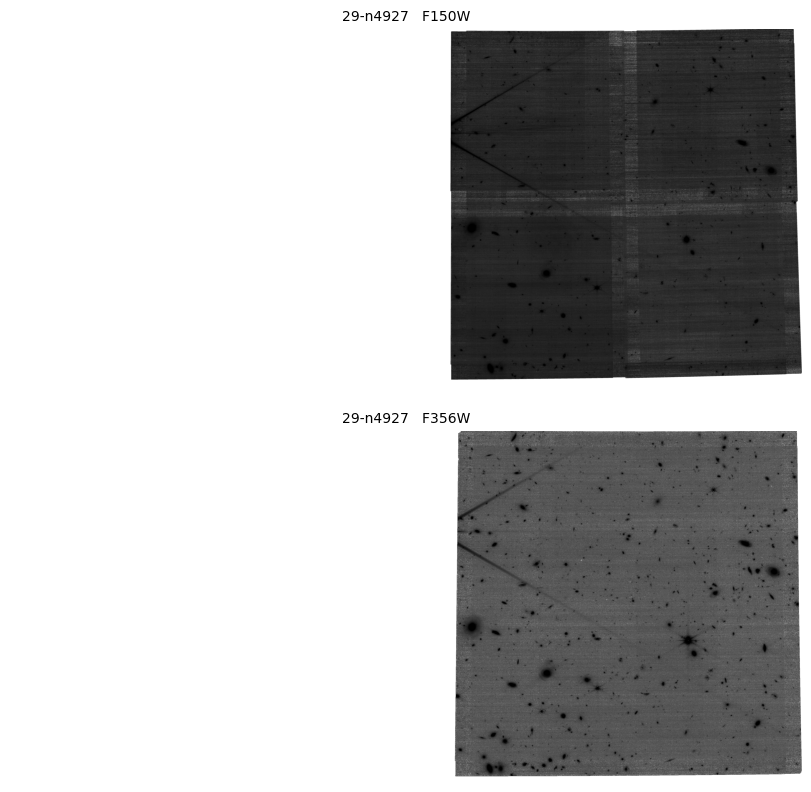

In [37]:
data1 = fits.getdata(sw_i2d_file, 'SCI')
data2 = fits.getdata(lw_i2d_file, 'SCI')
print(sw_i2d_file)

fig, ax = plt.subplots(2, 1, figsize=(8,8), constrained_layout=True)

norm = simple_norm(data1, stretch='log', percent=99)
ax[0].imshow(data1, origin='lower', norm=norm, cmap='gray_r')
ax[0].set_title(name + '   ' + filters[-2], fontsize=10)
ax[0].set_aspect('equal')
ax[0].axis('off')

norm = simple_norm(data2, stretch='log', percent=99)
ax[1].imshow(data2, origin='lower', norm=norm, cmap='gray_r')
ax[1].set_title(name + '   ' + filters[-1], fontsize=10)
ax[1].set_aspect('equal')
ax[1].axis('off')

plt.show()

/Users/joejensen/data/jwst-5989/rawdata/29-n4927/stage3flicker/n4927_F150W_flicker_i2d.fits


Text(0.5, 1.0, '29-n4927   F150W')

(np.float64(-0.5), np.float64(10072.5), np.float64(-0.5), np.float64(4573.5))

Text(0.5, 1.0, '29-n4927   F356W')

(np.float64(-0.5), np.float64(4963.5), np.float64(-0.5), np.float64(2203.5))

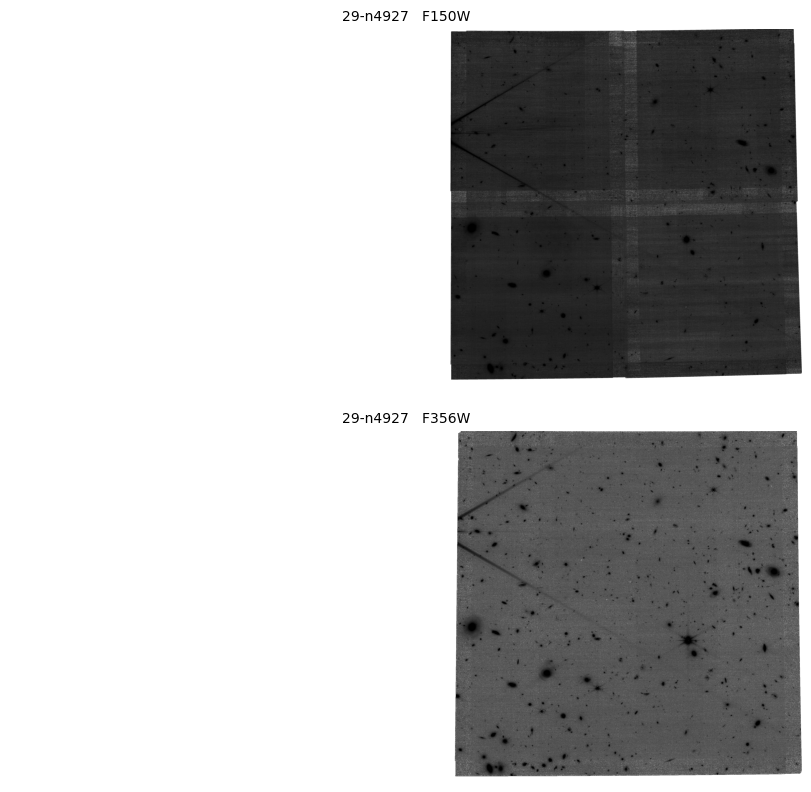

In [38]:
if correctflicker:
    data1 = fits.getdata(sw_i2d_file_flicker, 'SCI')
    data2 = fits.getdata(lw_i2d_file_flicker, 'SCI')
    print(sw_i2d_file_flicker)
    
    fig, ax = plt.subplots(2, 1, figsize=(8,8), constrained_layout=True)
    
    norm = simple_norm(data1, stretch='log', percent=99)
    ax[0].imshow(data1, origin='lower', norm=norm, cmap='gray_r')
    ax[0].set_title(name + '   ' + filters[-2], fontsize=10)
    ax[0].set_aspect('equal')
    ax[0].axis('off')
    
    norm = simple_norm(data2, stretch='log', percent=99)
    ax[1].imshow(data2, origin='lower', norm=norm, cmap='gray_r')
    ax[1].set_title(name + '   ' + filters[-1], fontsize=10)
    ax[1].set_aspect('equal')
    ax[1].axis('off')
    
    plt.show()